# Distributed Finetuning: A Practical Guide

## Why This Tutorial Exists

You've downloaded a 7B-parameter model. You've prepared your dataset. You fire up your finetuning script and — **CUDA out of memory**. Sound familiar?

The core problem is straightforward: modern LLMs are too large to finetune on a single GPU. But the *reason* they're too large isn't just about model weights. Most engineers underestimate GPU memory requirements by 4–8x because they only think about parameters. Training memory is a very different beast from inference memory.

This tutorial walks through the theory of distributed finetuning — the techniques that let you split the memory and compute burden across multiple GPUs so that training models at the billion-parameter scale becomes practical.

---

## What Consumes GPU Memory During Training?

When you train (or finetune) a model, four components compete for VRAM:

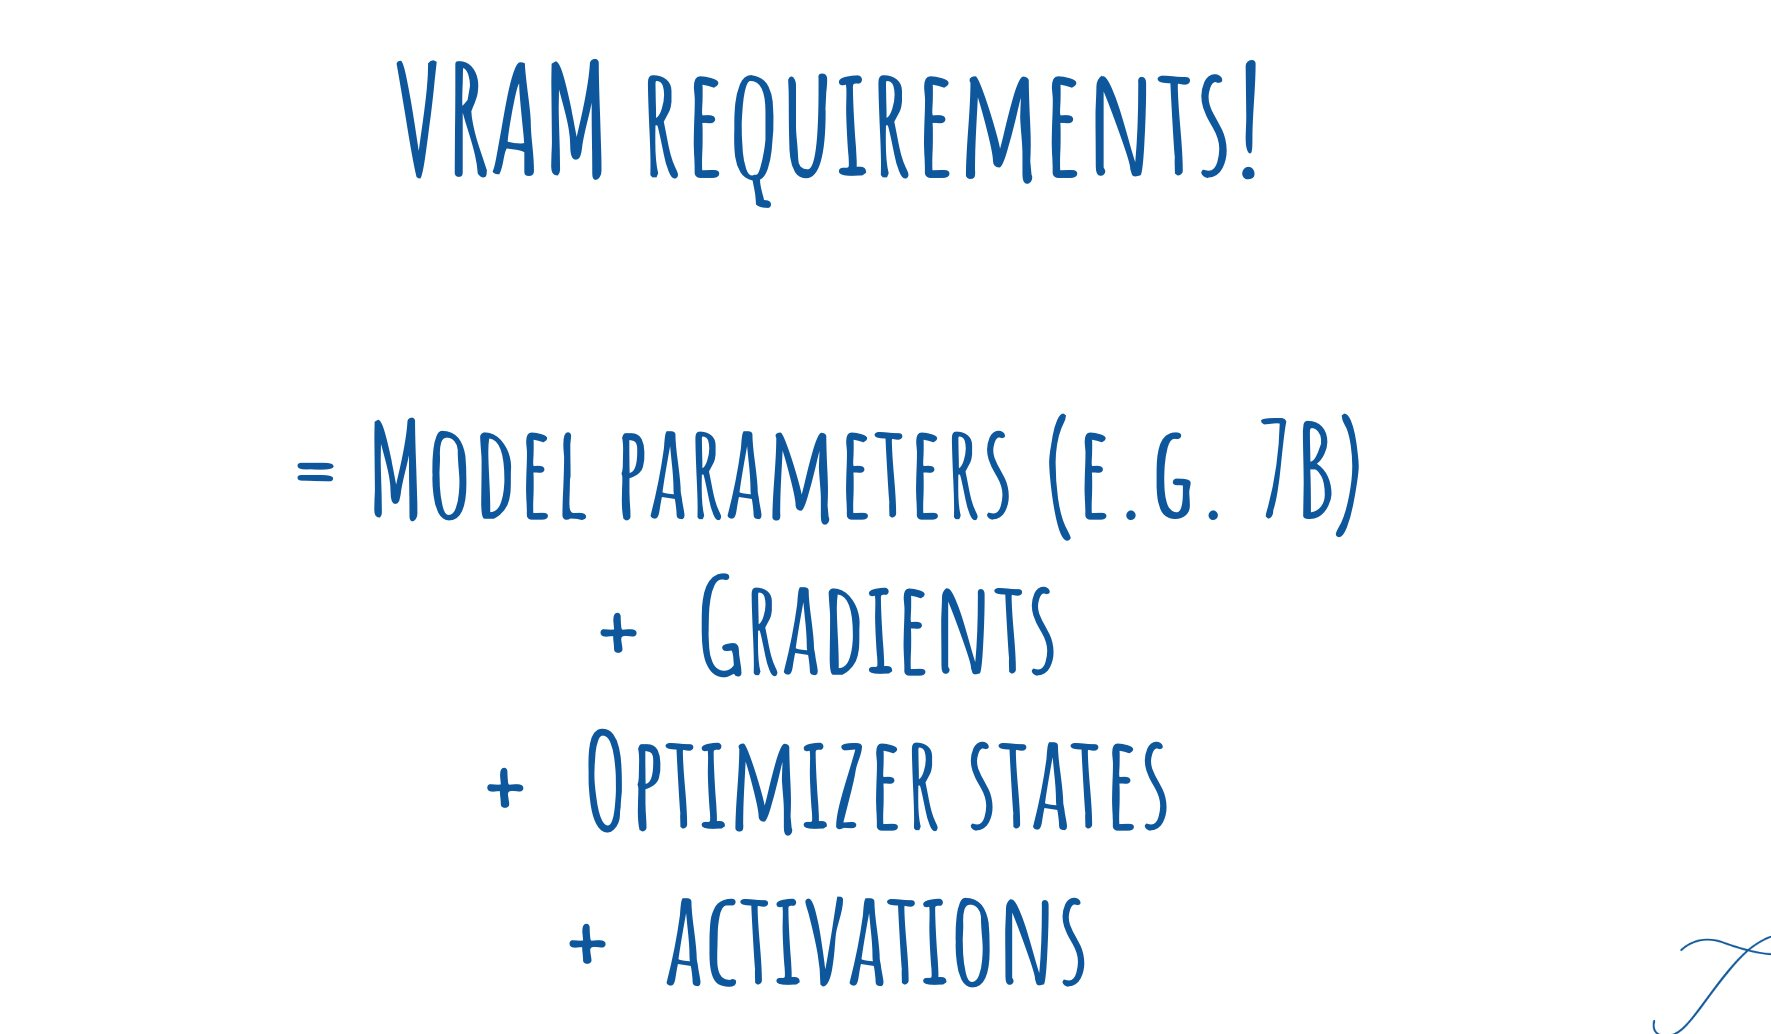

Let's break each one down.

### 1. Model Parameters

These are the learned weights and biases of the neural network — the numbers that define what the model "knows." The memory footprint depends on the parameter count and the numerical precision you store them in:

| Precision | Bytes per Parameter | 7B Model Weights |
|-----------|-------------------|-----------------|
| FP32      | 4 bytes           | ~28 GB          |
| FP16 / BF16 | 2 bytes        | ~14 GB          |
| INT8      | 1 byte            | ~7 GB           |
| INT4      | 0.5 bytes         | ~3.5 GB         |

For inference, this is essentially all you need (plus some KV cache overhead). For training, this is just the beginning.

### 2. Gradients

During backpropagation, a gradient is computed for every trainable parameter. Each gradient has the same shape and precision as the parameter it corresponds to. So if your model parameters occupy 14 GB in FP16, expect another **~14 GB for gradients**.

### 3. Optimizer States

This is where most engineers get surprised. Optimizers like Adam and AdamW don't just store the current gradient — they maintain *running statistics* for every parameter. Specifically, Adam tracks:

- **First moment (momentum)**: an exponential moving average of past gradients
- **Second moment (variance)**: an exponential moving average of squared past gradients
- **A master copy of the parameters in FP32** (when using mixed-precision training)

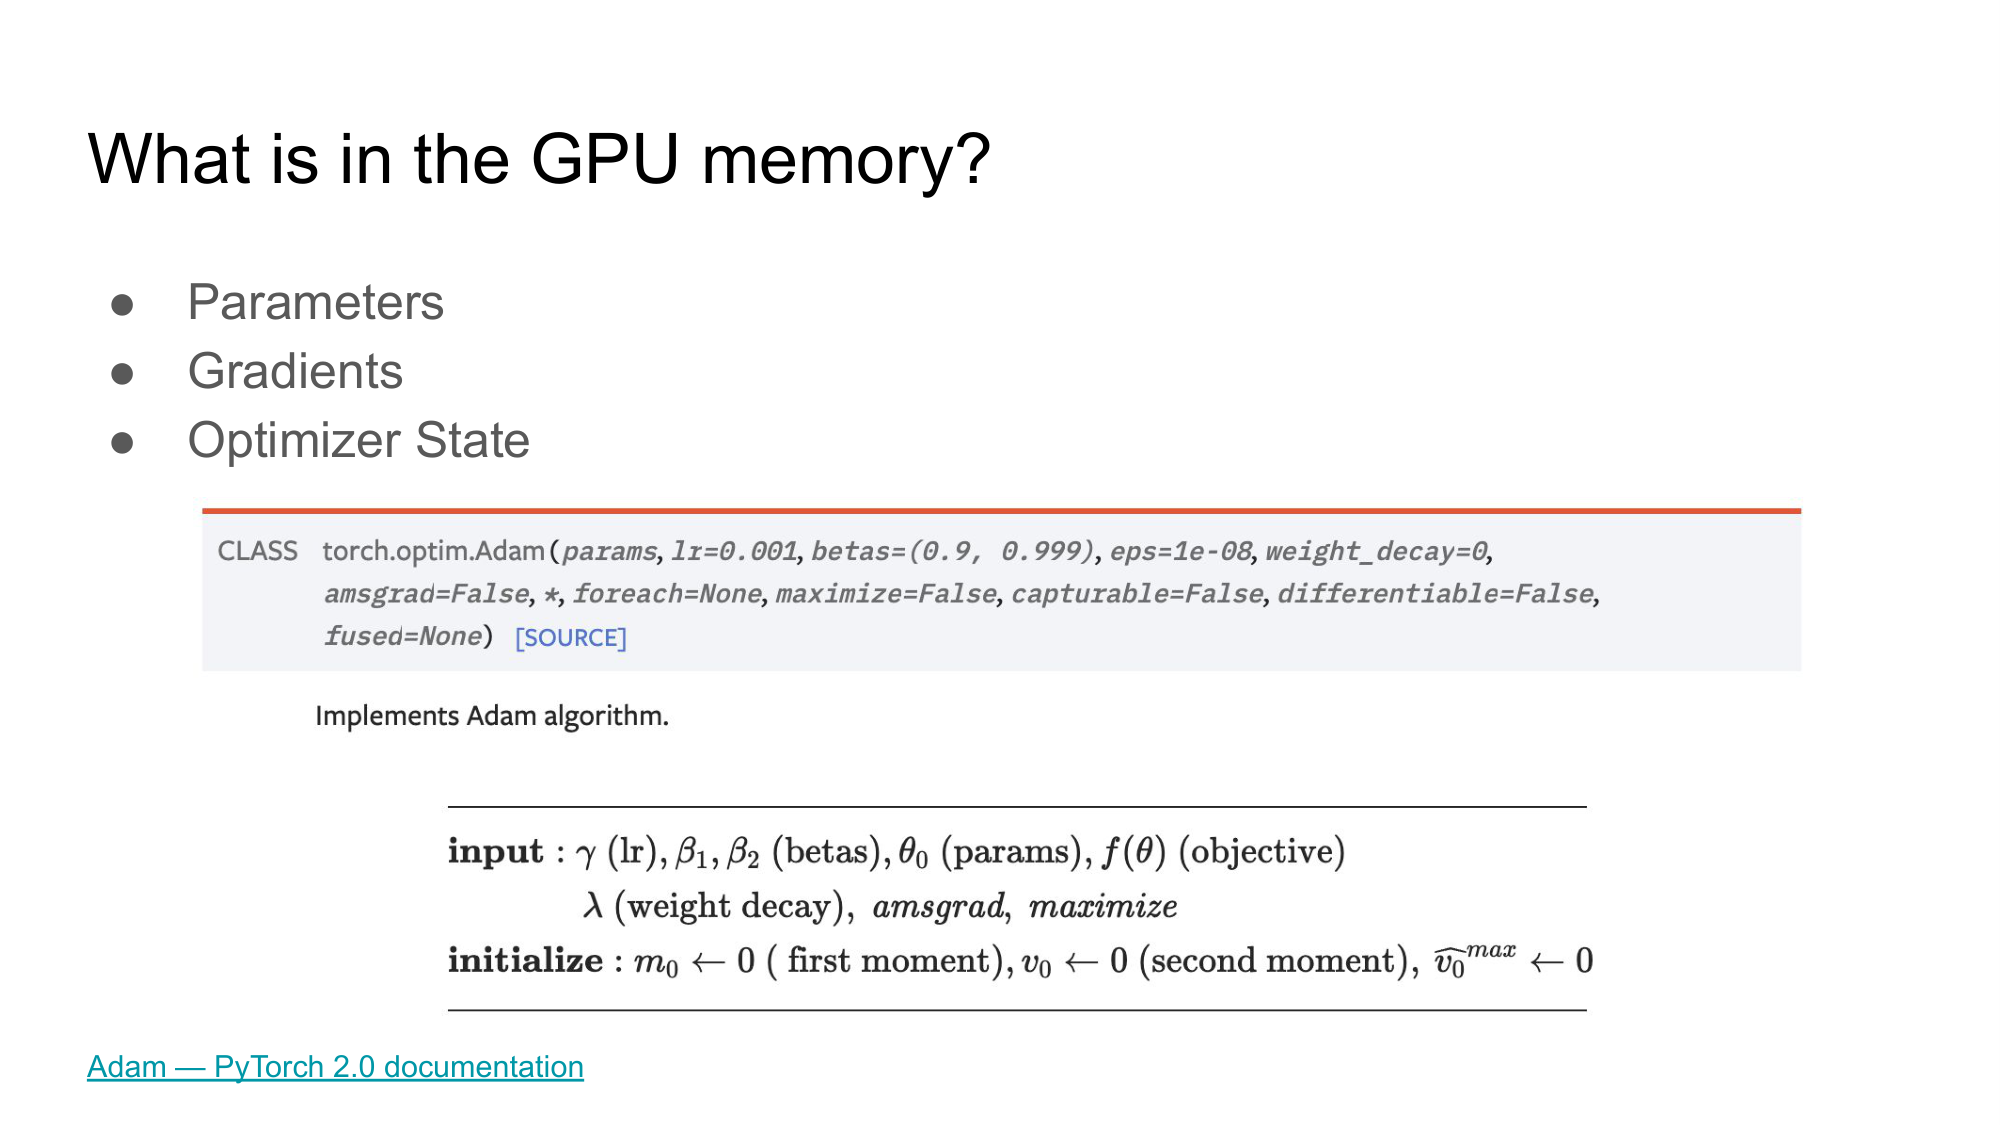

The Adam update equations make this concrete:

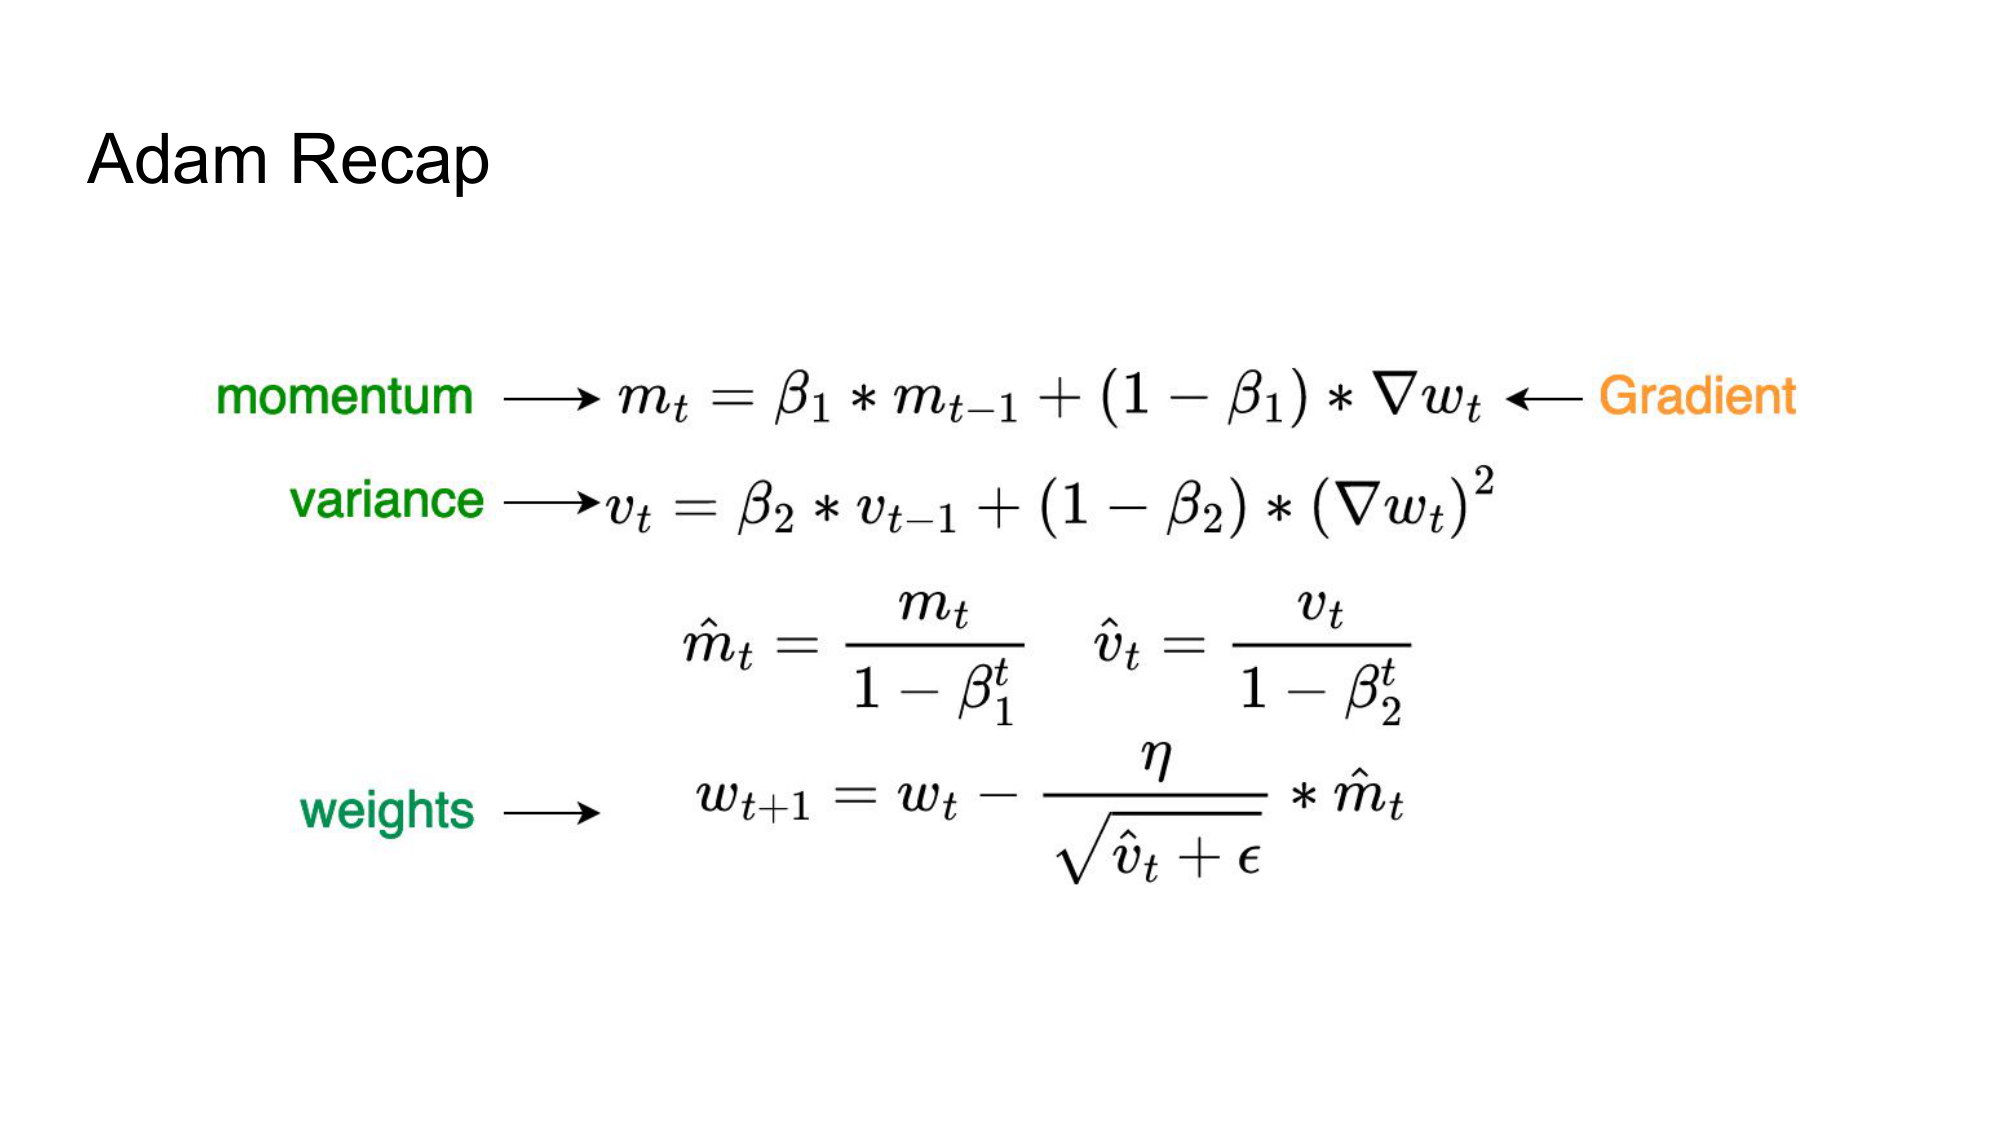

Each of these three quantities — the FP32 parameter copy, momentum, and variance — is stored at full 32-bit precision for numerical stability. That's 4 bytes × 3 = **12 bytes per parameter** just for optimizer state.

### 4. Activations

Activations are the intermediate outputs computed during the forward pass. They must be kept in memory because backpropagation needs them to compute gradients. Activation memory depends on batch size, sequence length, hidden dimension, and the number of layers. Techniques like gradient/activation checkpointing can trade compute for memory here by recomputing activations instead of storing them.

> **Note:** The presentation slides omit activations from the analysis for simplicity. In practice, activations can dominate memory for large batch sizes and long sequences, but for the purpose of understanding parallelism strategies, the parameters + gradients + optimizer states breakdown is the key mental model.

---

## The Math: Total Training Memory

Putting it all together for mixed-precision training with Adam and a model with **Ψ** parameters:

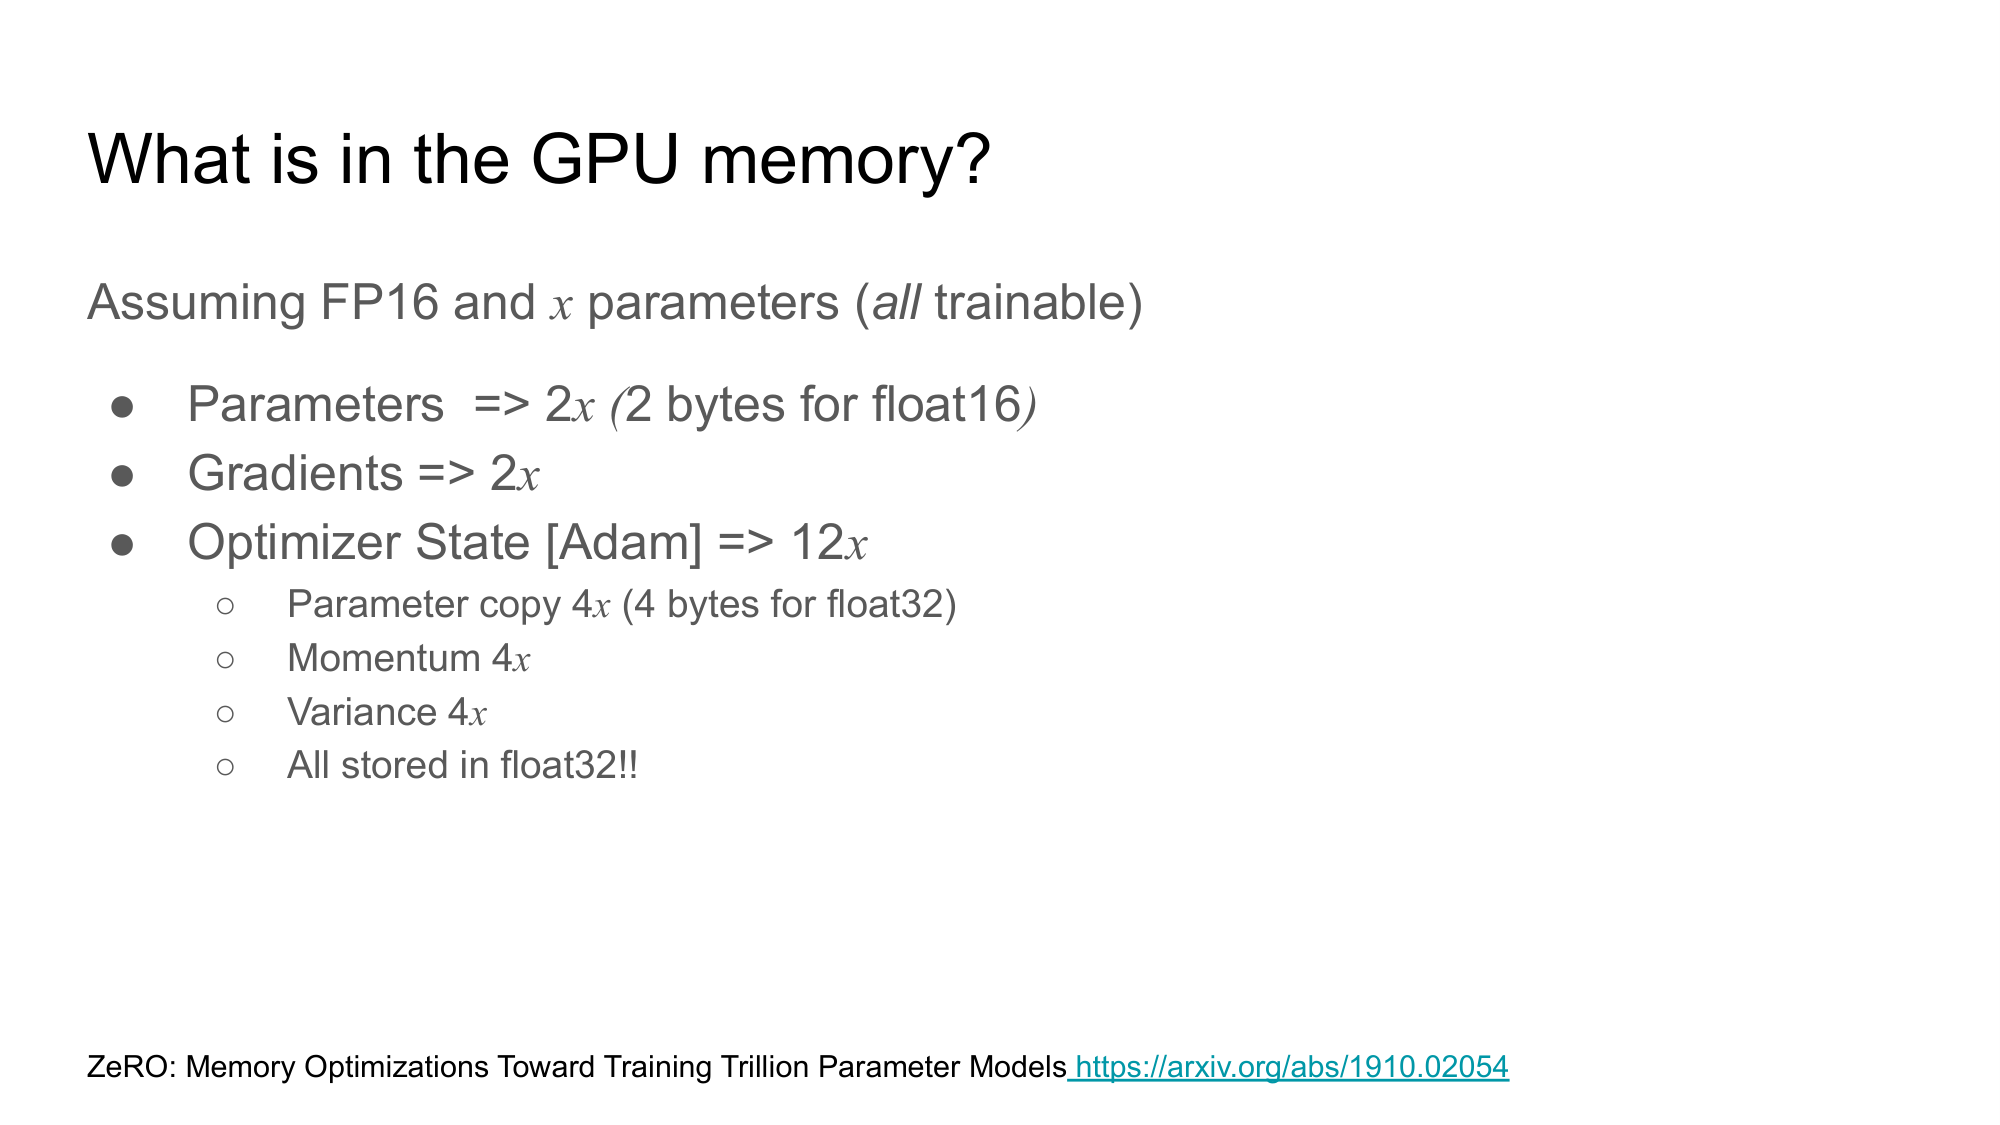

| Component           | Memory (bytes)     | 7B Model (FP16 + Adam) |
|---------------------|-------------------|------------------------|
| Parameters (FP16)   | 2Ψ                | 14 GB                  |
| Gradients (FP16)    | 2Ψ                | 14 GB                  |
| Optimizer — FP32 copy | 4Ψ              | 28 GB                  |
| Optimizer — Momentum  | 4Ψ              | 28 GB                  |
| Optimizer — Variance  | 4Ψ              | 28 GB                  |
| **Total**           | **(2 + 2 + K) × Ψ** | **~112 GB**        |

Where **K = 12** for Adam (4 + 4 + 4 bytes per parameter for the three FP32 optimizer states).

The formula **(2 + 2 + K) × Ψ** comes directly from the ZeRO paper. For a 7.5B parameter model with Adam, the baseline memory per GPU works out to approximately **120 GB** — well beyond what any single consumer or even most data-center GPUs offer.

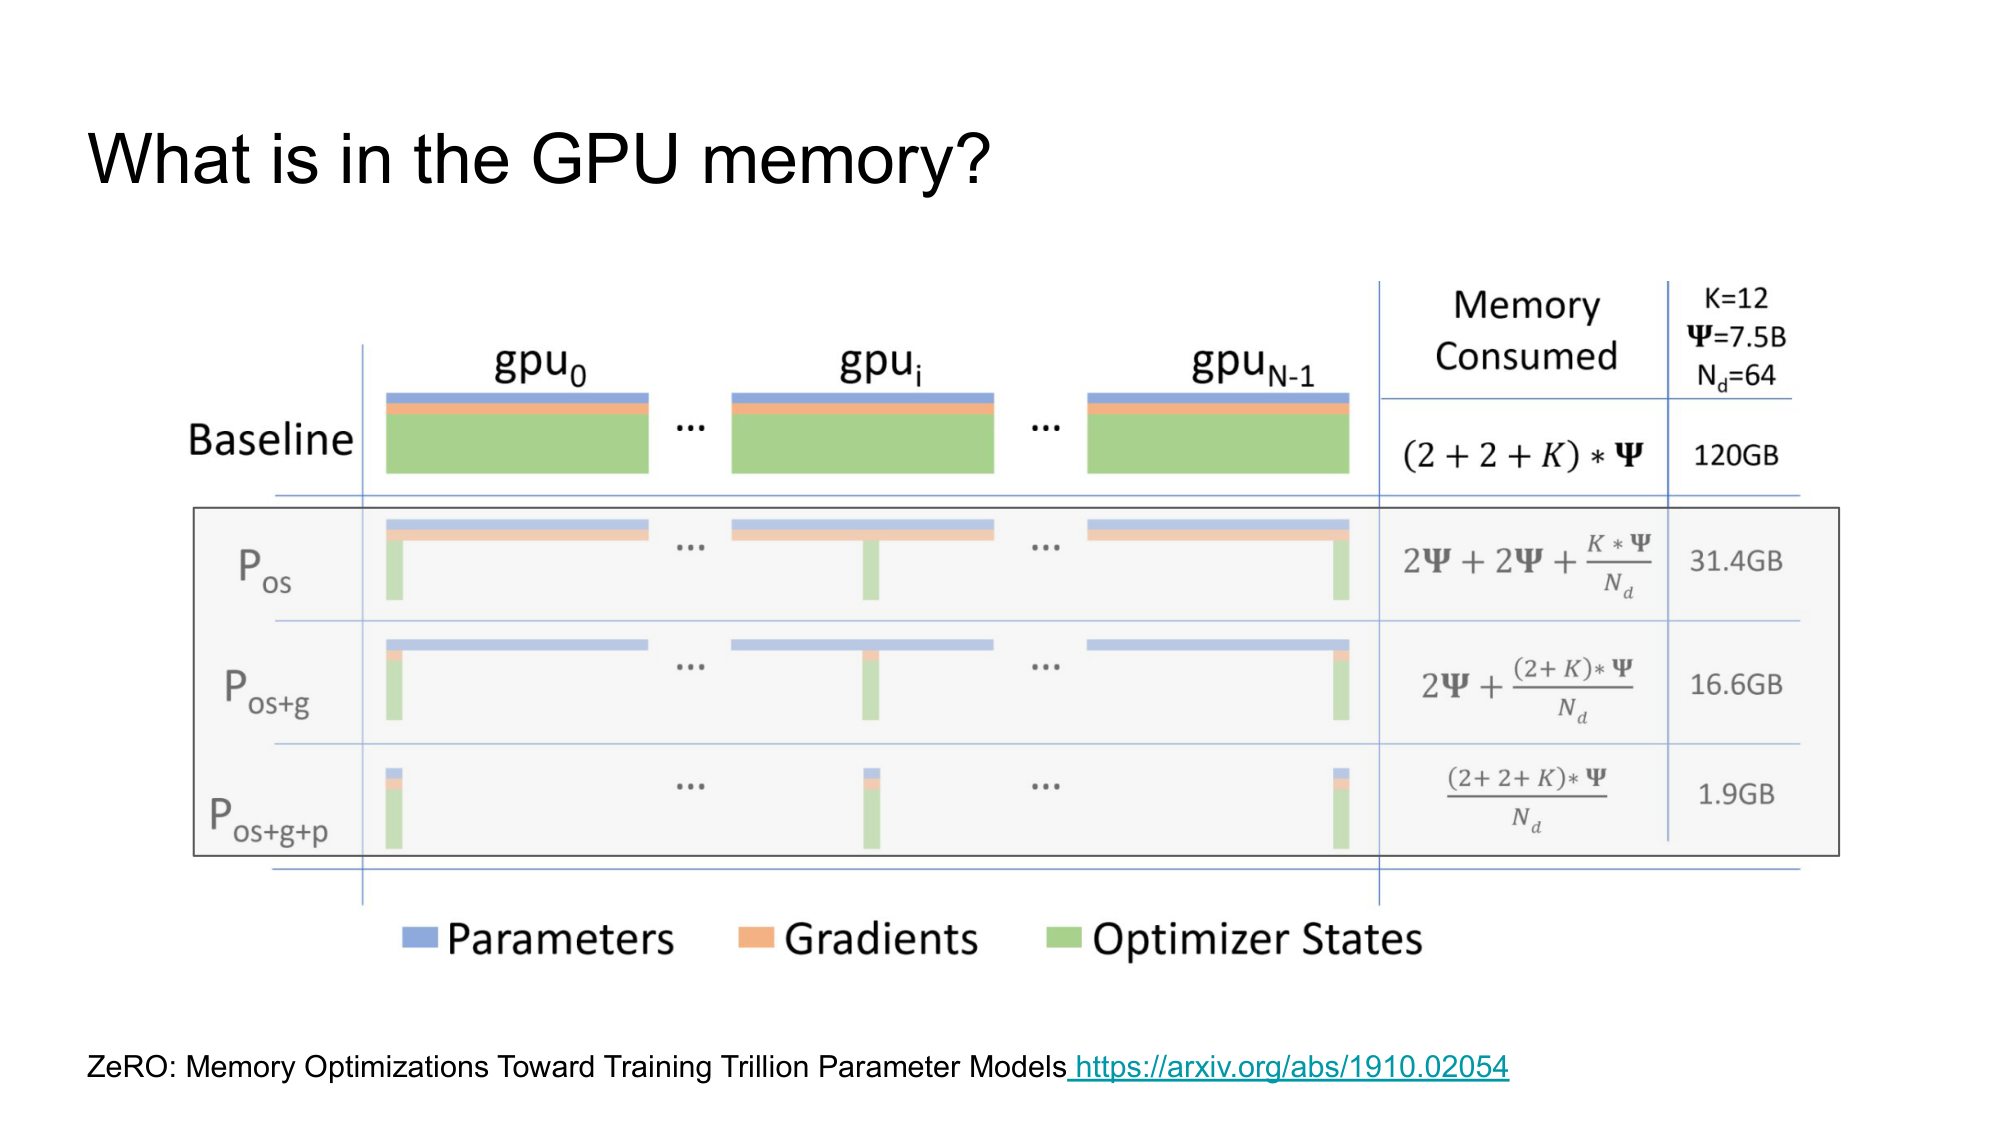

The ZeRO diagram above (from [Rajbhandari et al., 2019](https://arxiv.org/abs/1910.02054)) shows this baseline and previews the solution: by partitioning optimizer states, gradients, and parameters across N GPUs, memory per device drops dramatically. We'll cover this in detail when we discuss FSDP and DeepSpeed ZeRO.

---

## The Gap: Why a Single GPU Isn't Enough

A quick rule of thumb for full finetuning: **~16 GB of VRAM per 1B parameters**. That means:

| Model Size | Approx. Training VRAM | Fits on a Single A100 80GB? |
|------------|----------------------|----------------------------|
| 1B         | ~16 GB               | Yes                         |
| 7B         | ~112 GB              | No                          |
| 13B        | ~208 GB              | No                          |
| 70B        | ~1,120 GB            | No                          |

Even an NVIDIA A100 with 80 GB of HBM2e can't finetune a 7B model with standard Adam in FP16 without running out of memory. This is the fundamental motivation for distributed training.

There are two broad categories of solutions:

1. **Reduce what you're training** — techniques like LoRA, QLoRA, and adapter methods freeze most parameters and only train a small subset. This is effective but changes the optimization dynamics.

2. **Distribute the training across GPUs** — techniques like DDP, FSDP, DeepSpeed ZeRO, pipeline parallelism, and tensor parallelism split the memory burden across multiple devices. The model trains as if it were on a single giant GPU.

This tutorial focuses on category 2. In the sections that follow, we'll build up from the simplest distributed approach (DDP) to the most memory-efficient (FSDP / ZeRO Stage 3), covering the communication primitives, the tradeoffs, and when to use each strategy.

---

## What's Next

In the next section, we'll start with the communication foundation that all distributed training relies on: **NCCL (NVIDIA Collective Communication Library)** and its core primitives — Reduce, AllReduce, AllGather, and ReduceScatter. Understanding these operations is essential before we can see how DDP and FSDP actually work under the hood.

---

## References

- Rajbhandari, S., Rasley, J., Rabe, O., & He, Y. (2019). *ZeRO: Memory Optimizations Toward Training Trillion Parameter Models*. [arXiv:1910.02054](https://arxiv.org/abs/1910.02054)
- Zhao, Y., et al. (2023). *PyTorch FSDP: Experiences on Scaling Fully Sharded Data Parallel*. [arXiv:2304.11277](https://arxiv.org/abs/2304.11277)
- Lu, Y. (2024). *How much VRAM do I need for LLM model fine-tuning?* [Modal Blog](https://modal.com/blog/how-much-vram-need-fine-tuning)

# Parallelism Strategies: What FSDP is *Not*

Before we dive into FSDP and DDP, it's important to understand the three parallelism strategies that FSDP is **not**. These are complementary techniques — each solves the "model too big for one GPU" problem differently, and in practice they're often combined with data parallelism (DDP/FSDP) in production training.

---

## 1. Model Parallelism (Naive / Vertical Split)

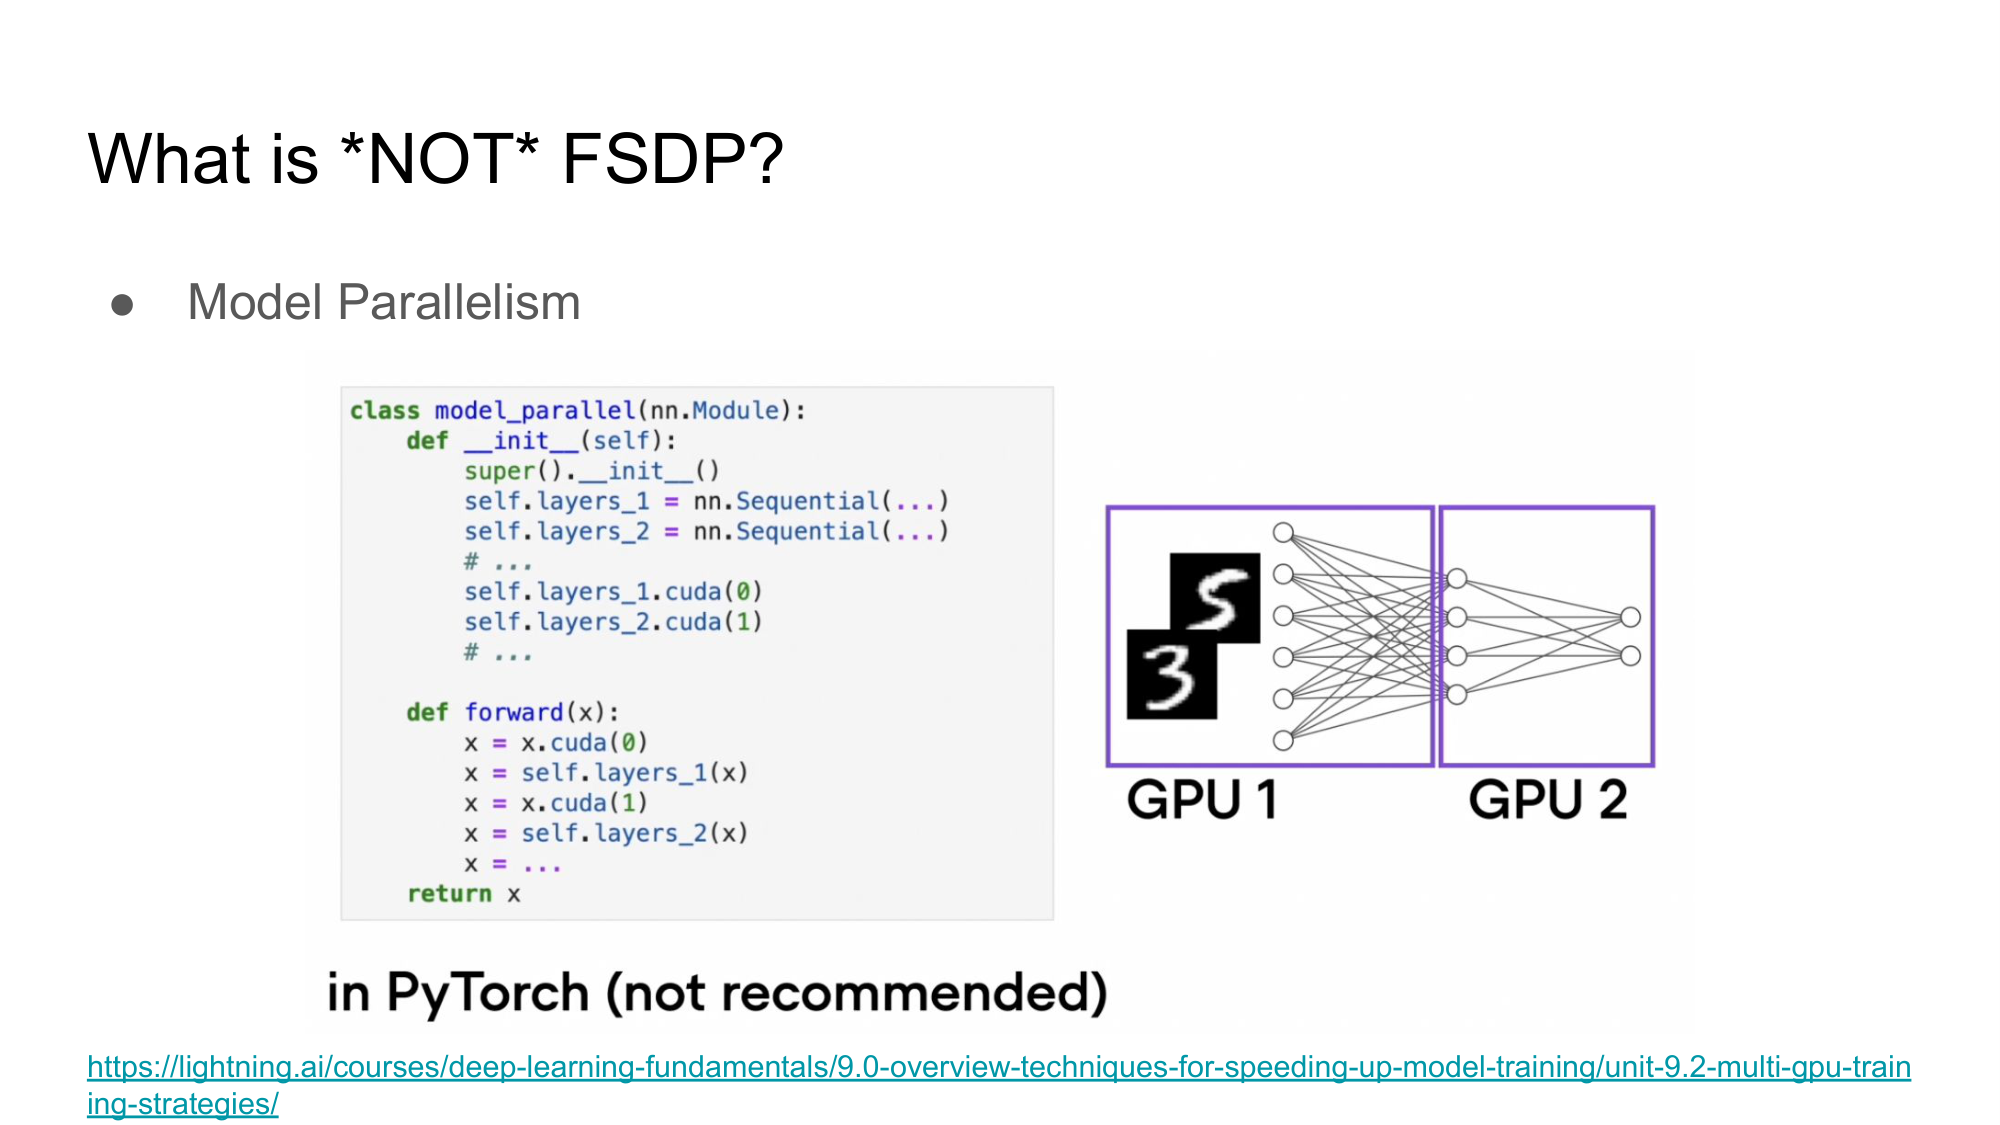

The simplest idea: assign different **layers** to different GPUs. In the code above, `layers_1` lives on `cuda(0)` and `layers_2` on `cuda(1)`. During the forward pass, GPU 0 computes its layers, sends activations to GPU 1, which computes the rest.

**The problem:** at any given moment, only one GPU is active. The others sit idle waiting for their turn. With N GPUs, each device is busy only ~1/N of the time. This is called the **pipeline bubble**, and it makes naive model parallelism impractical as a standalone strategy.

PyTorch itself marks this approach as "not recommended" — it solves the memory problem but creates a throughput disaster.

---

## 2. Tensor Parallelism (Horizontal Split)

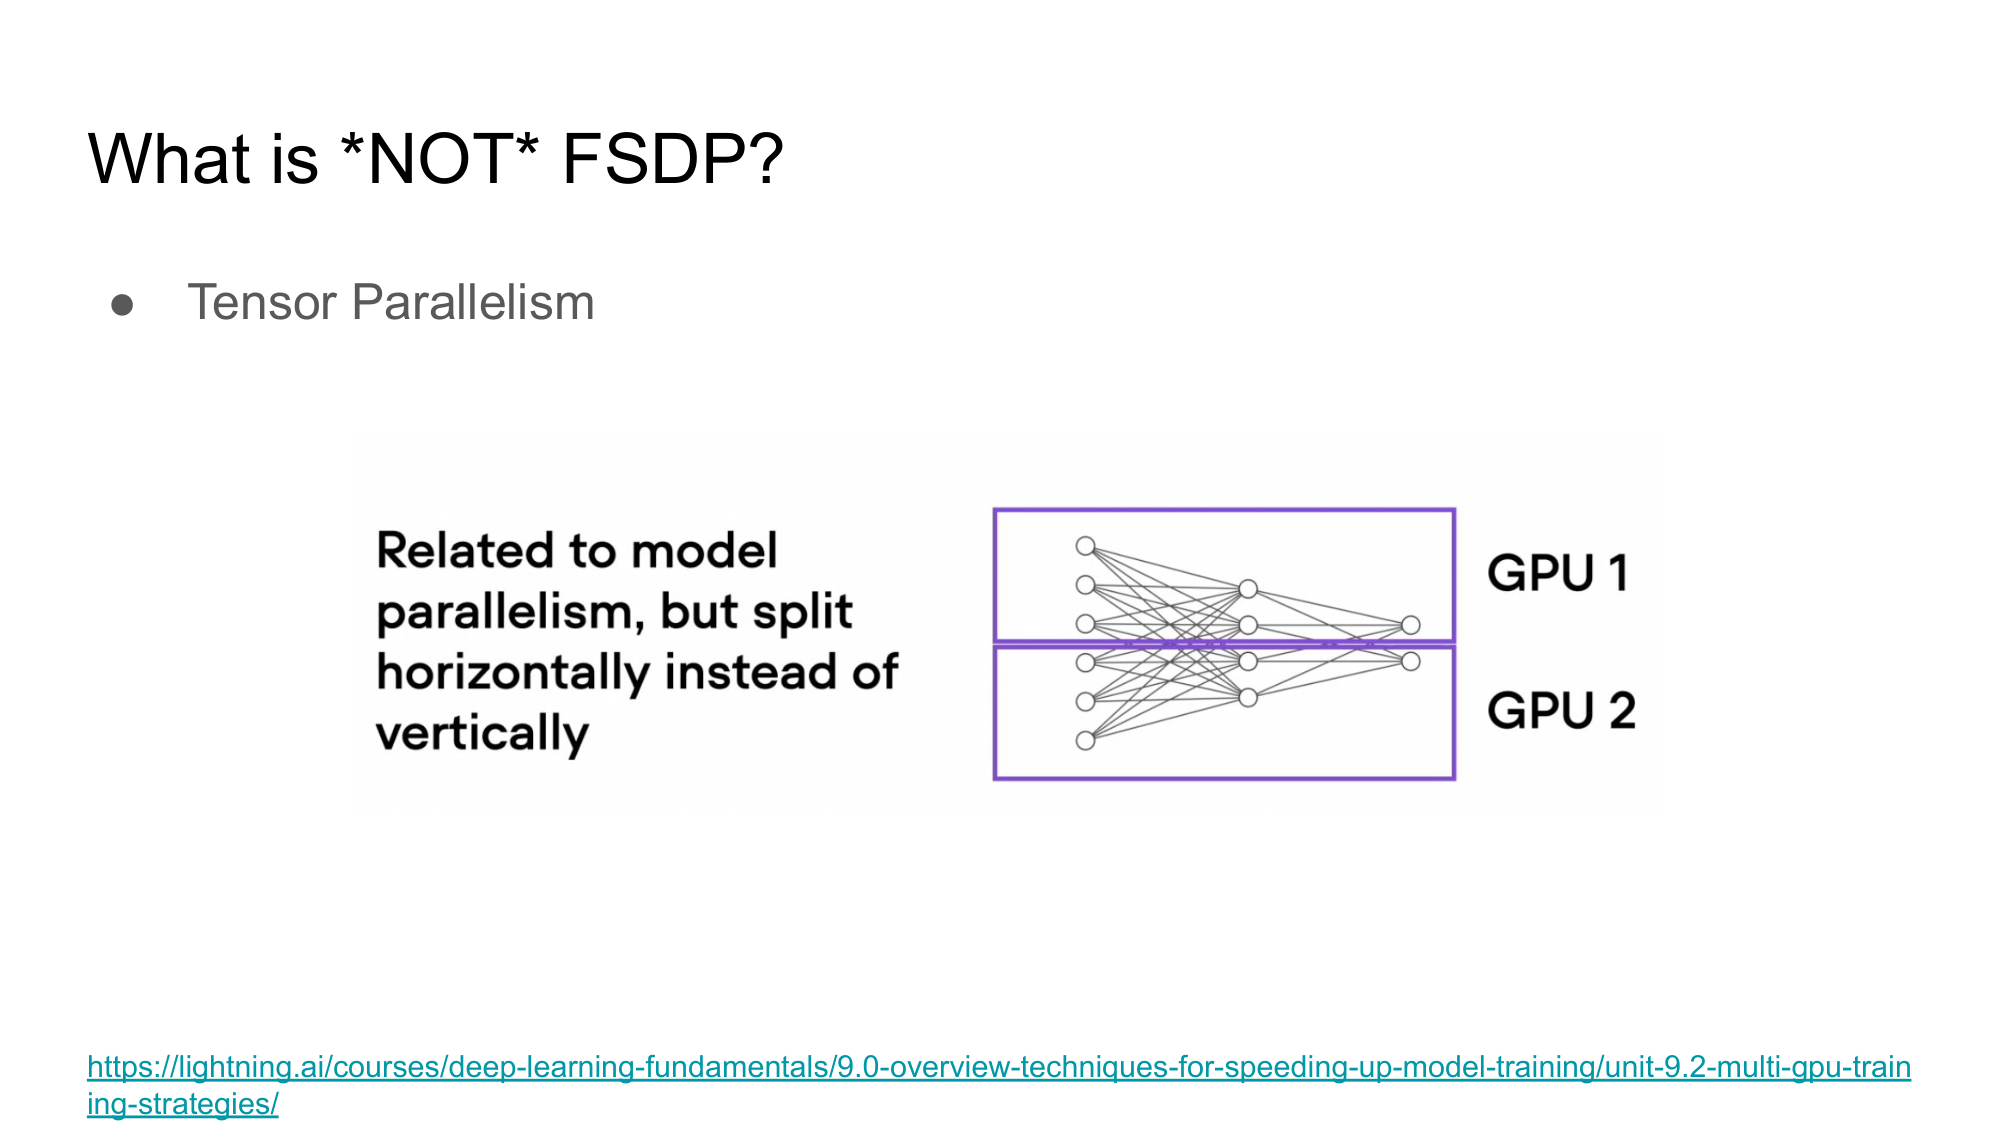

Instead of splitting by layer (vertically), tensor parallelism splits **within** a layer — dividing individual weight matrices horizontally across GPUs. Each GPU holds a slice of the weight matrix and computes a partial result.

For example, in a linear layer `Y = X · W`, if W has shape [4096, 16384], with 2-way TP each GPU holds [4096, 8192] and computes half the output columns. Results are combined via an **AllReduce** operation.

### How the matrix split works concretely

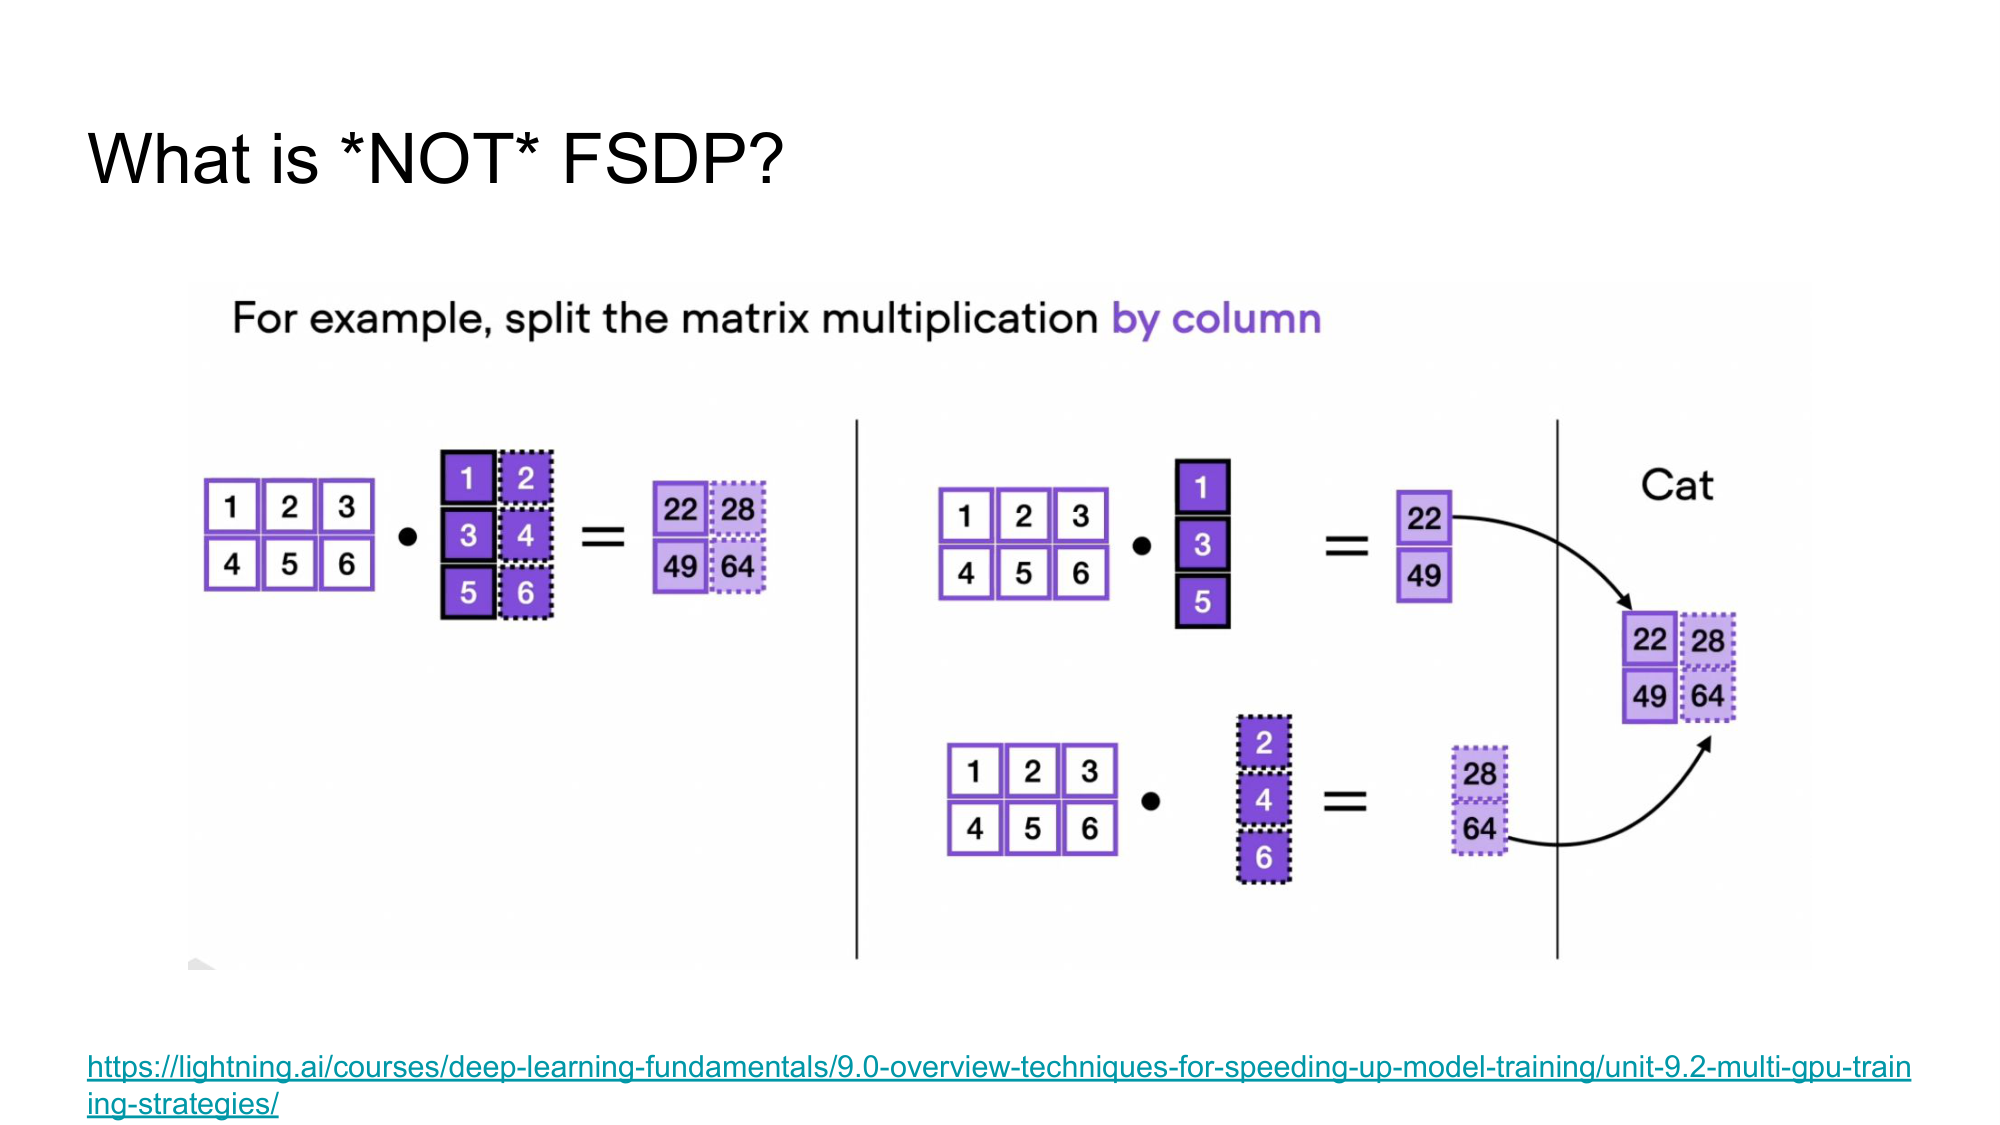

The example above shows a weight matrix split **by column** across 2 GPUs. Each GPU multiplies the full input by its column shard independently. The partial results are then concatenated (Cat) to produce the final output — identical to the single-GPU result.

This is the core idea behind Megatron-LM's tensor parallelism. In a Transformer MLP block, the first linear uses column-parallel splitting and the second uses row-parallel splitting, requiring only **one AllReduce per block**.

**Key constraint:** tensor parallelism requires extremely high-bandwidth interconnects (NVLink, 600–900 GB/s). It is almost always limited to **intra-node** (within a single 8-GPU server). Crossing node boundaries with TP can cut throughput in half.

---

## 3. Pipeline Parallelism (Model Parallelism + Micro-batching)

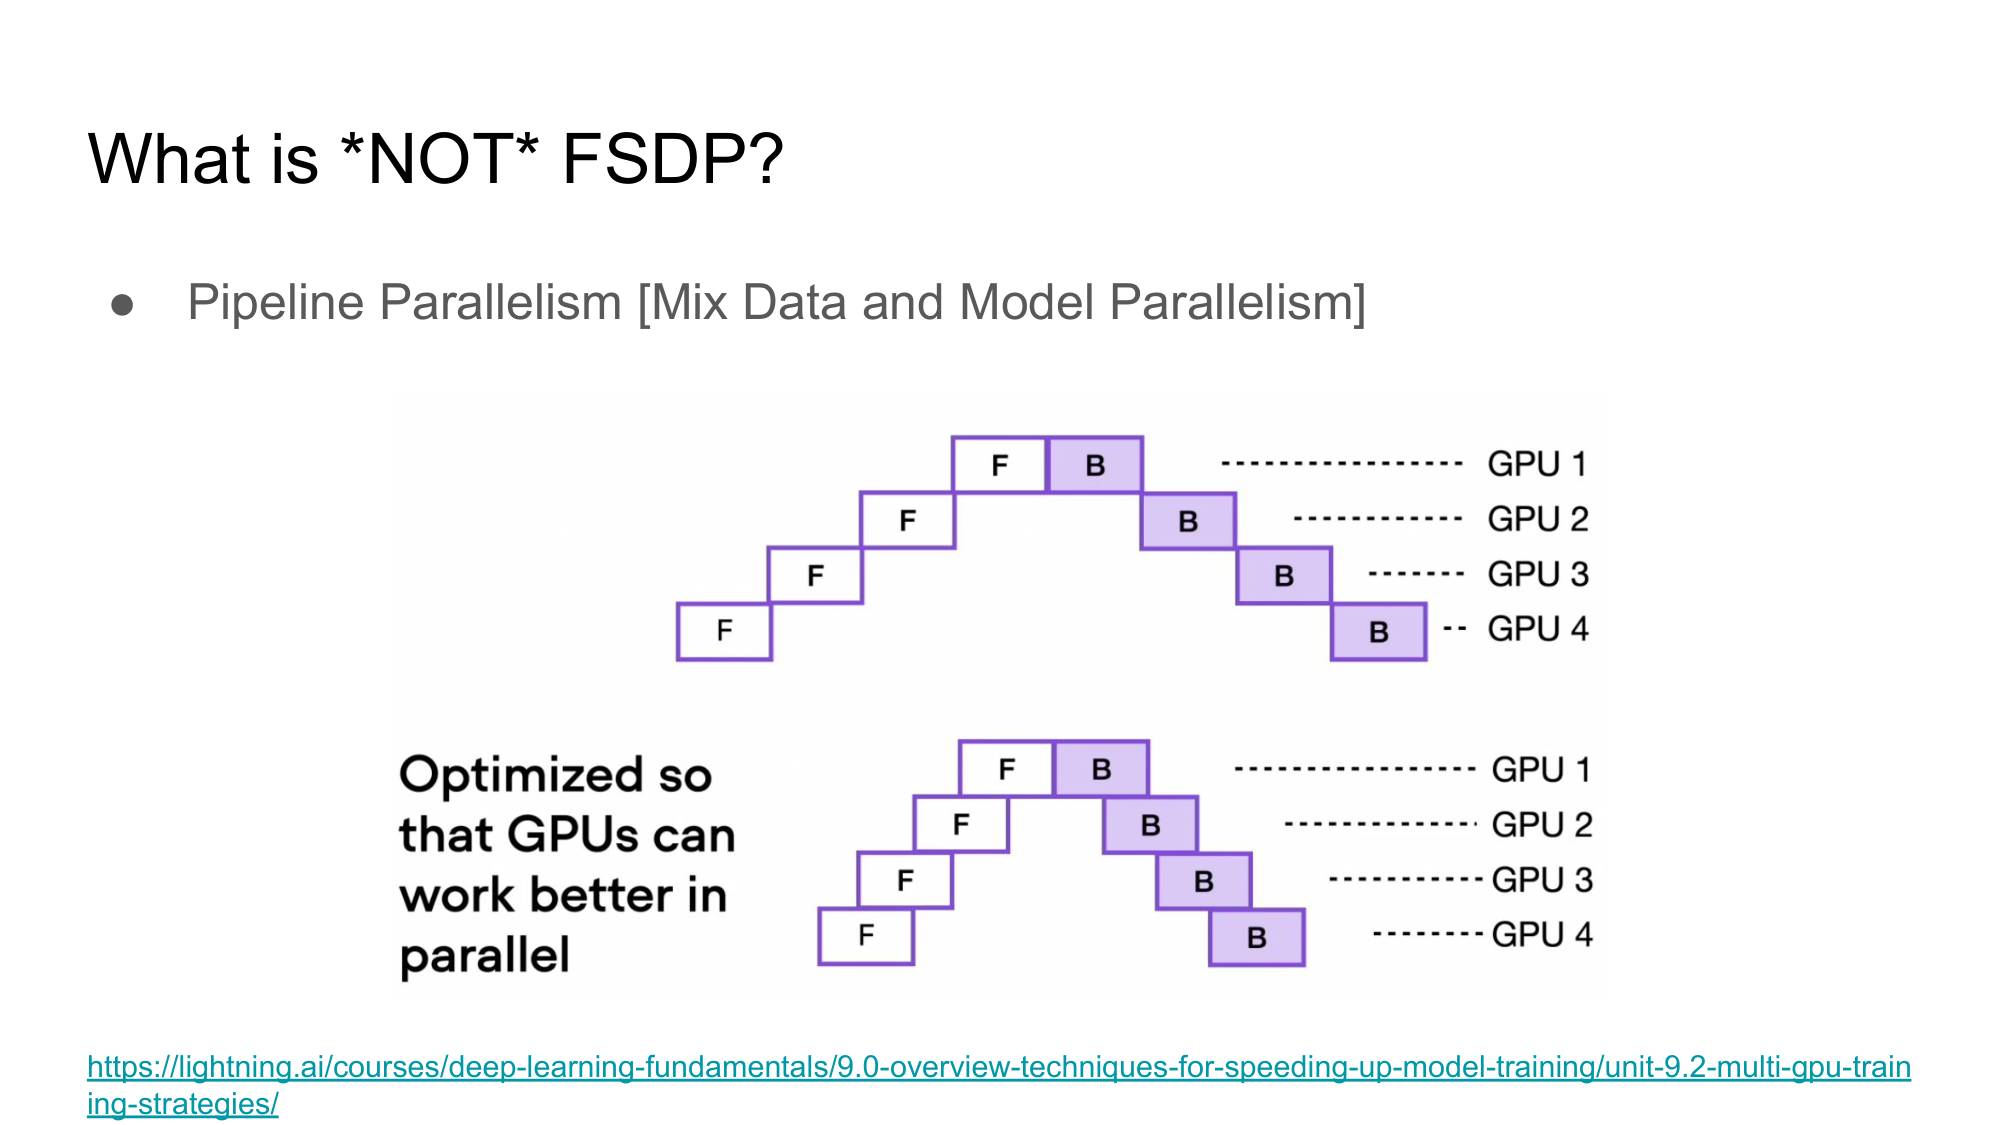

Pipeline parallelism takes the same vertical split as naive model parallelism but fixes the bubble problem by splitting each mini-batch into **M micro-batches** that flow through the pipeline concurrently.

The top diagram shows naive model parallelism: each GPU runs one Forward (F) then one Backward (B), creating massive idle time (dashed lines). The bottom diagram shows the optimized pipeline: micro-batches overlap, keeping GPUs busy in parallel.

The bubble fraction follows a simple formula:

**Bubble = (p − 1) / (m + p − 1)**

where **p** = number of pipeline stages and **m** = number of micro-batches. With 4 GPUs and 32 micro-batches, the bubble is only ~9%. The rule of thumb: use **m ≥ 4p** for reasonable efficiency.

Two main schedules exist:
- **GPipe** (Google): all forwards first, then all backwards. Simple, but stores activations for all M micro-batches simultaneously.
- **1F1B / PipeDream-Flush** (Microsoft): alternates one forward and one backward after warm-up. Same bubble fraction, but **halves peak activation memory**. This is the default in Megatron-LM and DeepSpeed.

---

## Summary: How They Compare

| Strategy | What's Split | Split Direction | Communication | Best Suited For |
|---|---|---|---|---|
| **Model Parallelism** (Naive) | Layers | Vertical | Point-to-point activations | Never use alone |
| **Tensor Parallelism** | Weight matrices | Horizontal | AllReduce (high bandwidth) | Intra-node (NVLink) |
| **Pipeline Parallelism** | Layer groups + micro-batches | Vertical | Point-to-point activations | Inter-node (InfiniBand) |
| **Data Parallelism** (DDP/FSDP) | Data batches (+ optional param sharding) | N/A | AllReduce gradients | Everywhere |

In production 3D parallelism setups (e.g., GPT-3, Llama 3), these combine as:
- **TP** within a node (8 GPUs via NVLink)
- **PP** across nodes (via InfiniBand)
- **DP/FSDP** across node groups

FSDP operates **orthogonally** to all three — it optimizes memory within the data-parallel dimension. That's why the next sections focus on DDP and FSDP as the practical workhorses for distributed finetuning.

---

## References

- Shoeybi, M., et al. (2019). *Megatron-LM: Training Multi-Billion Parameter Language Models Using Model Parallelism*. [arXiv:1909.08053](https://arxiv.org/abs/1909.08053)
- Huang, Y., et al. (2019). *GPipe: Efficient Training of Giant Neural Networks using Pipeline Parallelism*. [arXiv:1811.06965](https://arxiv.org/abs/1811.06965)
- Narayanan, D., et al. (2021). *Efficient Large-Scale Language Model Training on GPU Clusters Using Megatron-LM*. [arXiv:2104.04473](https://arxiv.org/abs/2104.04473)
- Rasley, J., et al. (2020). *DeepSpeed: System Optimizations Enable Training Deep Learning Models with Over 100 Billion Parameters*. [KDD 2020](https://www.deepspeed.ai/)
- Lightning AI. *Multi-GPU Training Strategies*. [Unit 9.2](https://lightning.ai/courses/deep-learning-fundamentals/9.0-overview-techniques-for-speeding-up-model-training/unit-9.2-multi-gpu-training-strategies/)

# NCCL Primitives & Distributed Data Parallel (DDP)

This section covers two things: the **communication primitives** that all distributed training relies on, and **DDP** — the simplest and most widely used distributed training strategy. Understanding both is essential before moving to FSDP.

---

## NCCL: The Communication Backbone

NCCL (NVIDIA Collective Communication Library) provides optimized multi-GPU communication routines over PCIe, NVLink, and InfiniBand. Every distributed training strategy — DDP, FSDP, DeepSpeed — uses NCCL under the hood. There are five core operations you need to know:

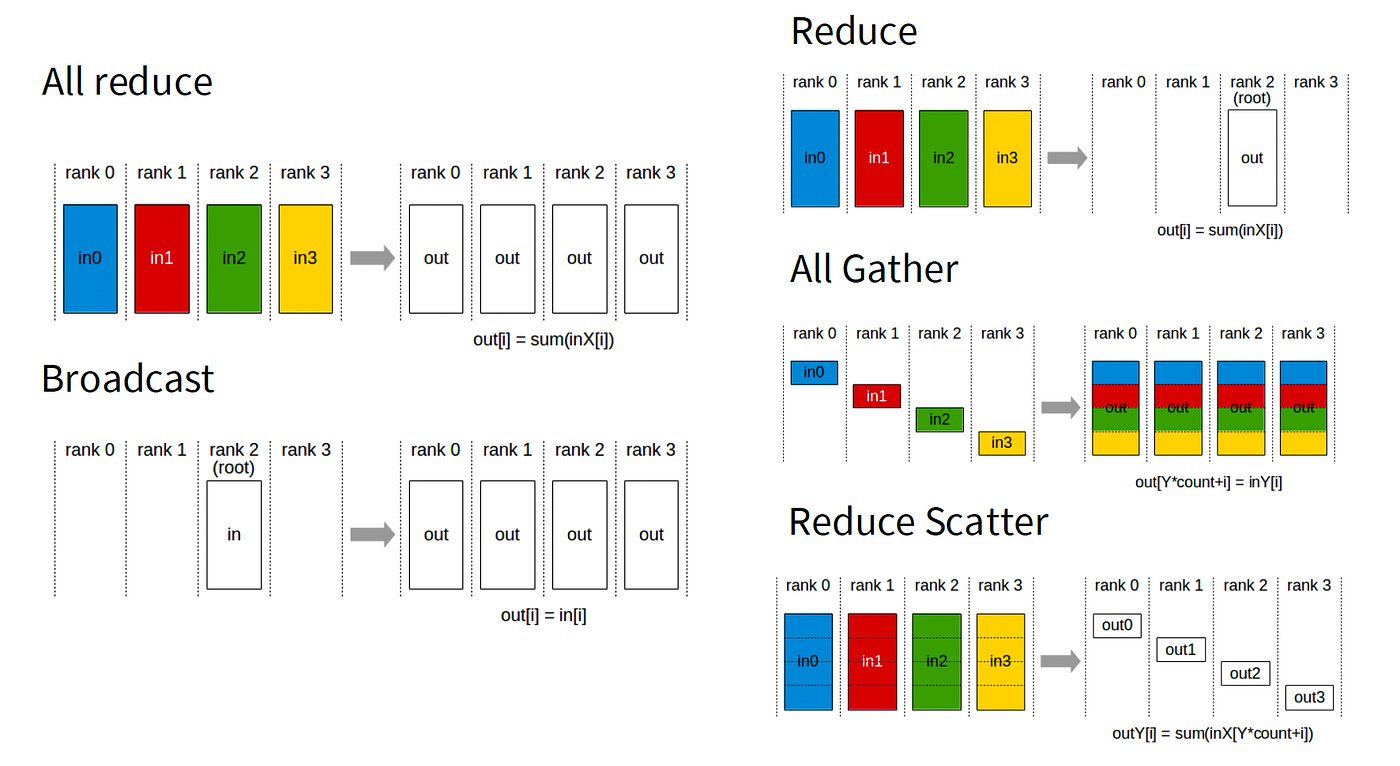

### Reduce

Every rank holds an input tensor. A reduction operation (typically **sum**) is applied across all ranks, and the result lands on a single **root** rank. All other ranks get nothing.

`out[i] = sum(inX[i])` — but only on the root.

**Used in:** Rare in modern training. Mostly a building block for other operations.

### AllReduce

Same as Reduce, but the result is **broadcast to all ranks**. Every rank ends up with an identical copy of the summed tensor.

`out[i] = sum(inX[i])` — on **every** rank.

**Used in:** DDP gradient synchronization. After backward pass, each GPU has local gradients computed on its own mini-batch. AllReduce sums (or averages) them so every GPU has the same global gradient. This is the **single most important operation for DDP**.

### Broadcast

One root rank sends its tensor to all other ranks. No reduction — pure replication.

`out[i] = in[i]` — copied from root to everyone.

**Used in:** Initializing model parameters. At the start of training, rank 0 broadcasts its weights so all GPUs begin with identical parameters.

### AllGather

Each rank holds a **different** small tensor (a shard). AllGather concatenates all shards and gives **every** rank the full concatenated result.

`out[Y*count+i] = inY[i]` — every rank gets the full picture.

**Used in:** FSDP forward pass. Parameters are sharded across GPUs; before computing a layer, AllGather reconstructs the full parameter tensor on every rank.

### ReduceScatter

Each rank holds a **full-sized** tensor. The operation reduces (sums) across ranks **and** scatters — each rank receives only its **own shard** of the reduced result.

`outY[i] = sum(inX[Y*count+i])` — each rank gets a different piece of the sum.

**Used in:** FSDP backward pass. After computing local gradients (full-sized), ReduceScatter sums gradients across GPUs and gives each GPU only its shard of the averaged gradient.

> **Key insight:** AllReduce = ReduceScatter + AllGather. DDP uses AllReduce (every rank needs full gradients). FSDP uses ReduceScatter + AllGather separately at different points to keep only shards in memory.

---

## Distributed Data Parallel (DDP)

DDP is the workhorse of multi-GPU training. The idea is simple: replicate the **entire model** on every GPU, give each GPU a **different mini-batch** of data, and synchronize gradients after the backward pass so all replicas update identically.

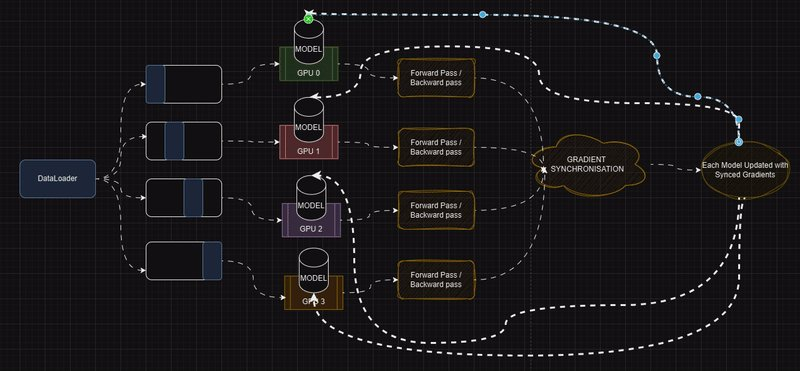

The flow above shows the full picture:

1. **DataLoader** splits the dataset into different mini-batches — one per GPU
2. Each GPU holds a **complete copy** of the model (parameters, optimizer states, gradients — everything)
3. Each GPU runs **forward + backward independently** on its own mini-batch
4. **Gradient Synchronization** — an AllReduce operation averages gradients across all GPUs
5. Each GPU applies the **same averaged gradient** to update its local model weights

Because every GPU starts with the same weights and applies the same averaged gradient, all replicas stay in sync. The training is mathematically equivalent to single-GPU training with a batch size of `per_gpu_batch × num_gpus`.

### The DDP Training Loop — Step by Step

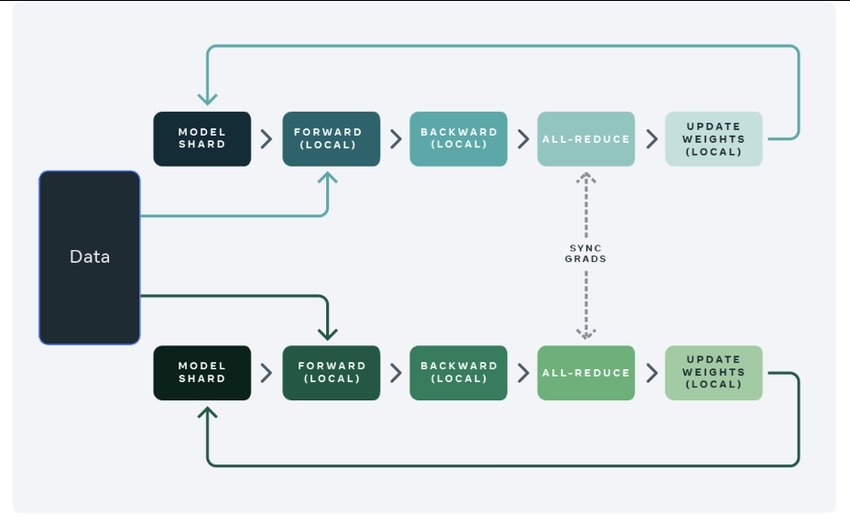

For each GPU on every training step:

1. **Forward (Local)** — each GPU runs the forward pass on its own data shard
2. **Backward (Local)** — each GPU computes gradients locally. At this point, GPU 0 has gradients from batch 0, GPU 1 from batch 1, etc. — they're all **different**
3. **AllReduce (Gradients)** — NCCL sums (or averages) gradients across all GPUs. After this, every GPU holds the **same global gradient** — as if training on the combined batch
4. **Update Weights (Local)** — each GPU runs the optimizer step independently. Since inputs (current weights + global gradient) are identical, outputs (new weights) are identical

The "Sync Grads" arrow between the two GPU pipelines above is the AllReduce — the **only** cross-GPU communication in the entire training step.

### DDP Memory: The Limitation

DDP replicates **everything** on every GPU:

| Component | Per GPU | 7B Model |
|---|---|---|
| Parameters (FP16) | 2Ψ | 14 GB |
| Gradients (FP16) | 2Ψ | 14 GB |
| Optimizer States (Adam FP32) | 12Ψ | 84 GB |
| **Total** | **16Ψ** | **~112 GB** |

Adding more GPUs does **not** reduce per-GPU memory — every GPU still holds the full model state. DDP only helps with **throughput** (processing more data per step), not with fitting larger models.

This is exactly the limitation that FSDP addresses. Where DDP replicates everything and only communicates gradients, FSDP **shards** parameters, gradients, and optimizer states across GPUs — reducing per-GPU memory proportionally to the number of devices.

### DDP Communication Cost

DDP performs **one AllReduce per training step**, transferring the full gradient tensor (same size as model parameters).

For a 7B model in FP16, that's ~14 GB of data per AllReduce. PyTorch optimizes this by **overlapping** the AllReduce with the backward pass — as soon as gradients for a layer are computed, they're sent while the next layer's gradients are still being calculated. This is called **bucketed gradient AllReduce** and it significantly hides communication latency.

Communication cost: **2Ψ bytes per step** (one AllReduce of the gradient tensor).

This is actually quite efficient. FSDP (ZeRO Stage 3) increases total communication by ~50% because it adds AllGather operations in the forward pass — trading communication for memory savings.

---

## When to Use DDP vs. When You Need More

**Use DDP when:**
- Your model fits on a single GPU (parameters + gradients + optimizer states)
- You want to scale throughput by training on more data in parallel
- You want the simplest distributed setup with minimal code changes

**Move to FSDP when:**
- Your model does NOT fit on a single GPU
- You need to shard optimizer states, gradients, or parameters across devices
- You're working with models at the billion-parameter scale

> DDP is essentially ZeRO Stage 0 — no sharding at all. The next section covers FSDP, which implements ZeRO Stages 1–3 natively in PyTorch.

---

## References

- Li, S., et al. (2020). *PyTorch Distributed: Experiences on Accelerating Data Parallel Training*. [arXiv:2006.15704](https://arxiv.org/abs/2006.15704)
- NVIDIA. *NCCL Collective Operations*. [User Guide](https://docs.nvidia.com/deeplearning/nccl/user-guide/docs/usage/collectives.html)
- Meta Engineering. (2021). *Fully Sharded Data Parallel: faster AI training with fewer GPUs*. [Engineering Blog](https://engineering.fb.com/2021/07/15/open-source/fsdp/)

# Fully Sharded Data Parallel (FSDP)

FSDP is PyTorch's native implementation of ZeRO Stage 3. Unlike DDP which replicates the full model on every GPU, FSDP **shards** parameters, gradients, and optimizer states across GPUs — reducing per-GPU memory proportionally to the number of devices.

The core tradeoff: FSDP uses **more communication** than DDP (AllGather + ReduceScatter instead of just AllReduce) but enables training models that would never fit on a single GPU.

---

## Key FSDP Concepts

Before diving into the mechanics, there are four terms specific to FSDP that you need to understand:

1. **FSDP Unit** — the granularity at which the model is split vertically
2. **Sharding** — how each FSDP unit's parameters are split horizontally across GPUs
3. **AllGather** — how sharded parameters are reconstructed before forward/backward
4. **ReduceScatter** — how gradients are reduced and re-sharded after backward

---

## 1. FSDP Unit (Vertical Splitting)

An FSDP unit defines how the model is **vertically partitioned** into groups of layers. Each unit is the atomic chunk that gets sharded, gathered, and freed together.

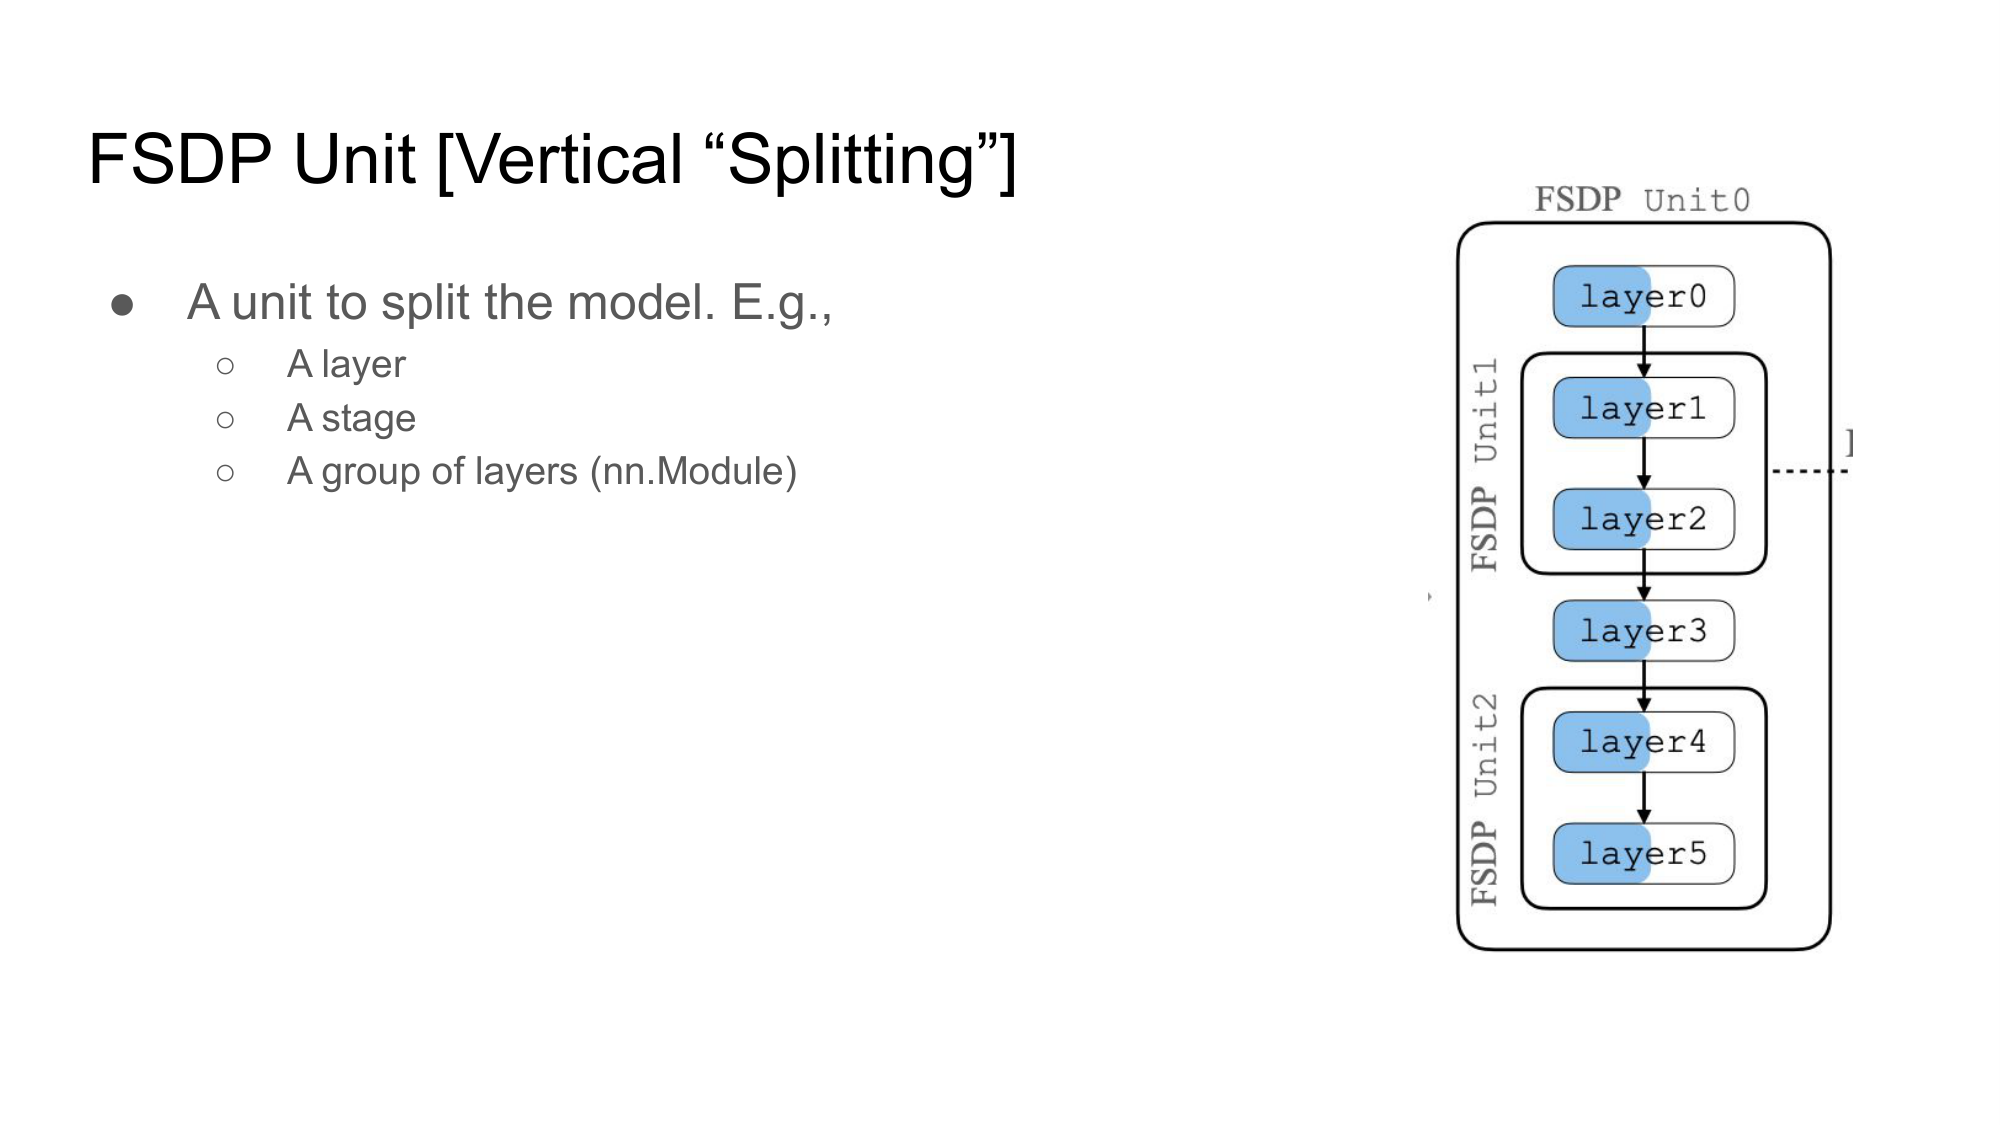

An FSDP unit can be a single layer, a group of layers, or an entire stage — whatever `nn.Module` boundary you choose. In the diagram, layers 0–2 form one unit and layers 3–5 form another. The choice of FSDP unit granularity affects:

- **Memory peak** — smaller units mean less memory needed when the full parameters are temporarily materialized
- **Communication overhead** — more units means more AllGather/ReduceScatter calls
- **Overlap efficiency** — more units gives more opportunities to overlap communication with computation

---

## 2. Sharding (Horizontal Splitting)

Within each FSDP unit, all parameters (weights, biases) are **flattened into a single 1D tensor** called `FlatParameter`. This FlatParameter is then evenly divided across all GPUs in the sharding group.

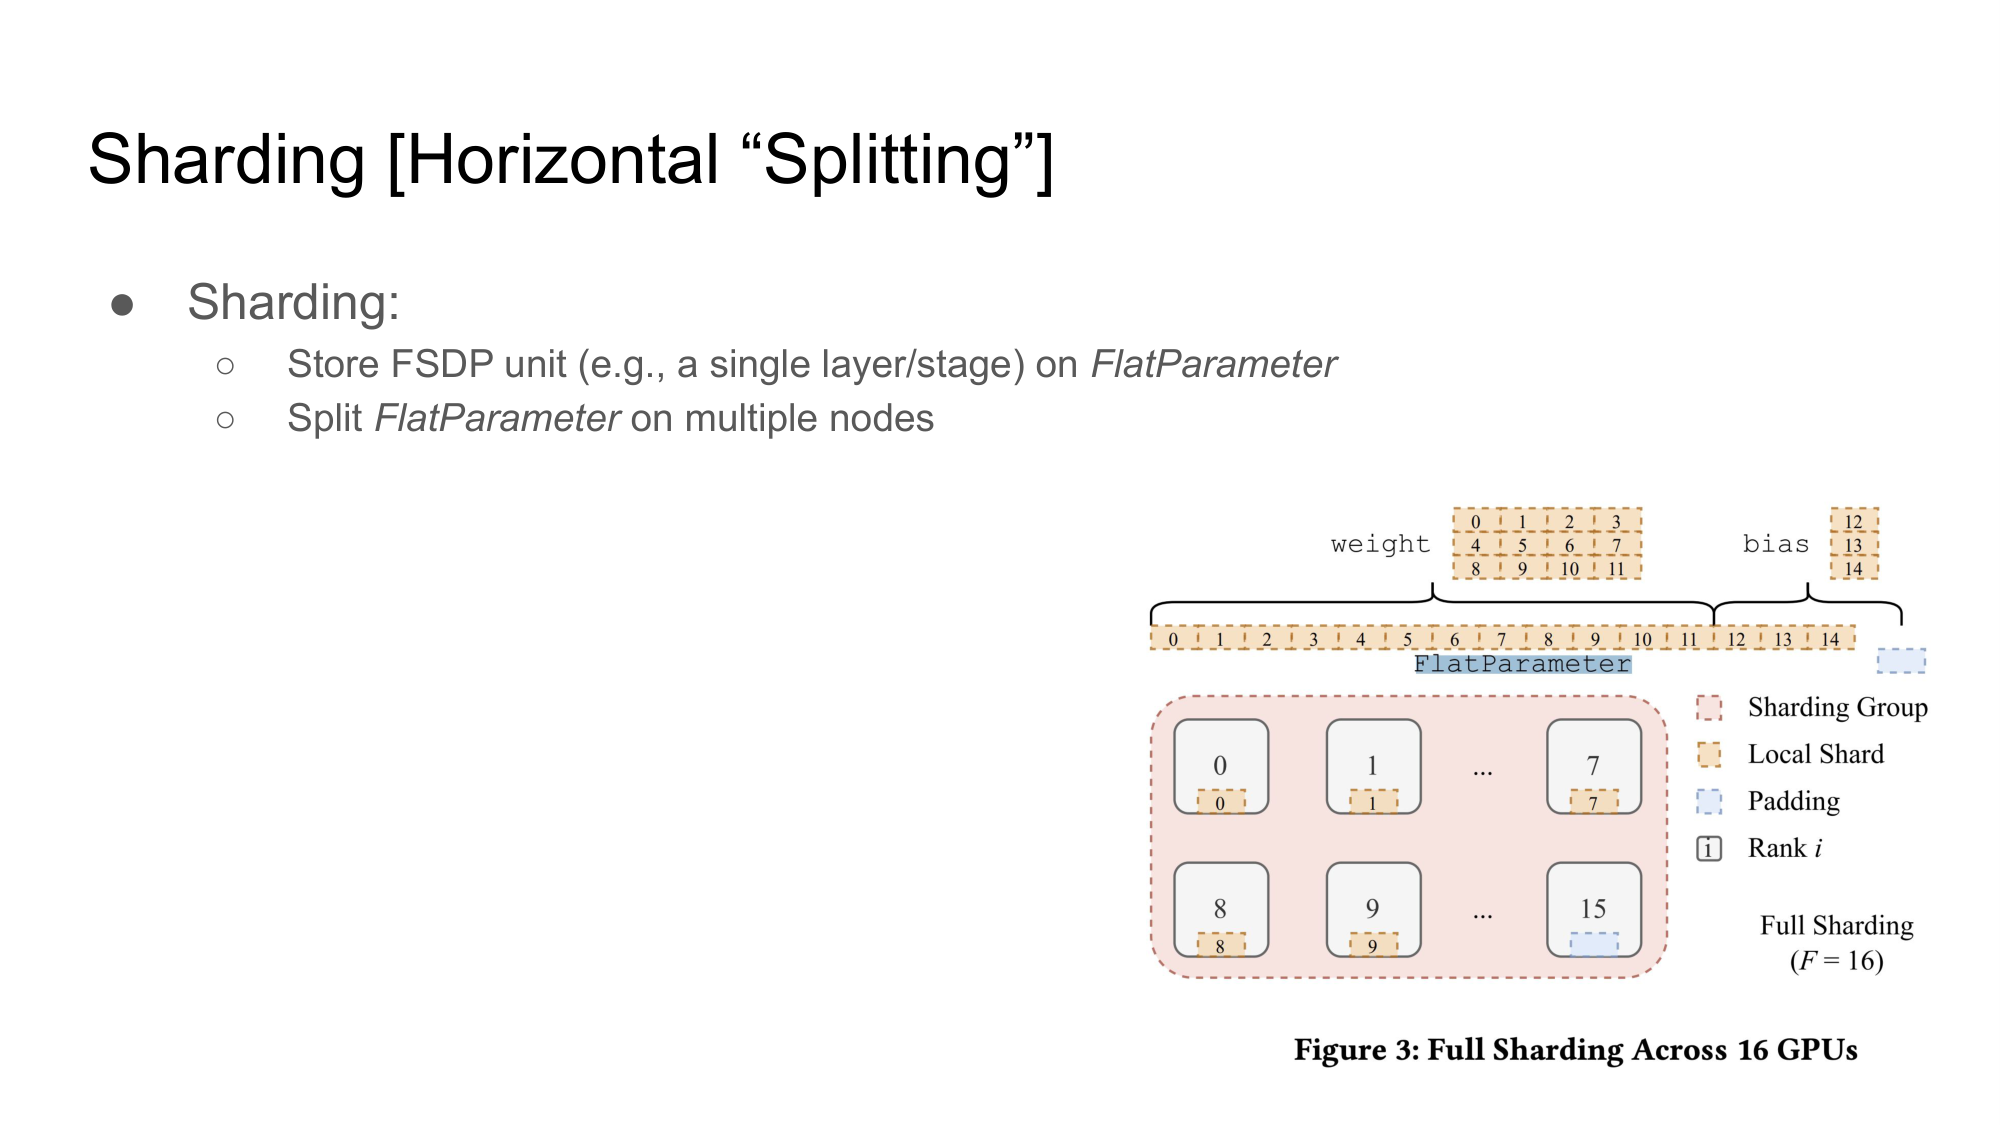

In the example above, a layer's weight matrix (12 values) and bias (3 values) are concatenated into a FlatParameter of 15 elements. With 16 GPUs (full sharding), each GPU stores only 1 element plus padding. Each GPU holds just its **local shard** — a tiny slice of the full parameter.

FSDP supports three sharding strategies (matching ZeRO stages):

| PyTorch Sharding Strategy | ZeRO Stage | What's Sharded | Memory per GPU |
|---|---|---|---|
| `NO_SHARD` | 0 (= DDP) | Nothing | (2 + 2 + K) × Ψ |
| `SHARD_GRAD_OP` | 2 | Optimizer states + Gradients | 2Ψ + (2+K)×Ψ / N |
| `FULL_SHARD` | 3 | Everything | (2 + 2 + K) × Ψ / N |

With `FULL_SHARD` on 64 GPUs and a 7B model: ~112 GB / 64 = **~1.75 GB per GPU**.

---

## 3. AllGather: Reconstructing Parameters On-Demand

Since each GPU only stores a shard of the parameters, the full parameter tensor must be **temporarily reconstructed** before a layer can run its forward or backward pass. This is done via AllGather.

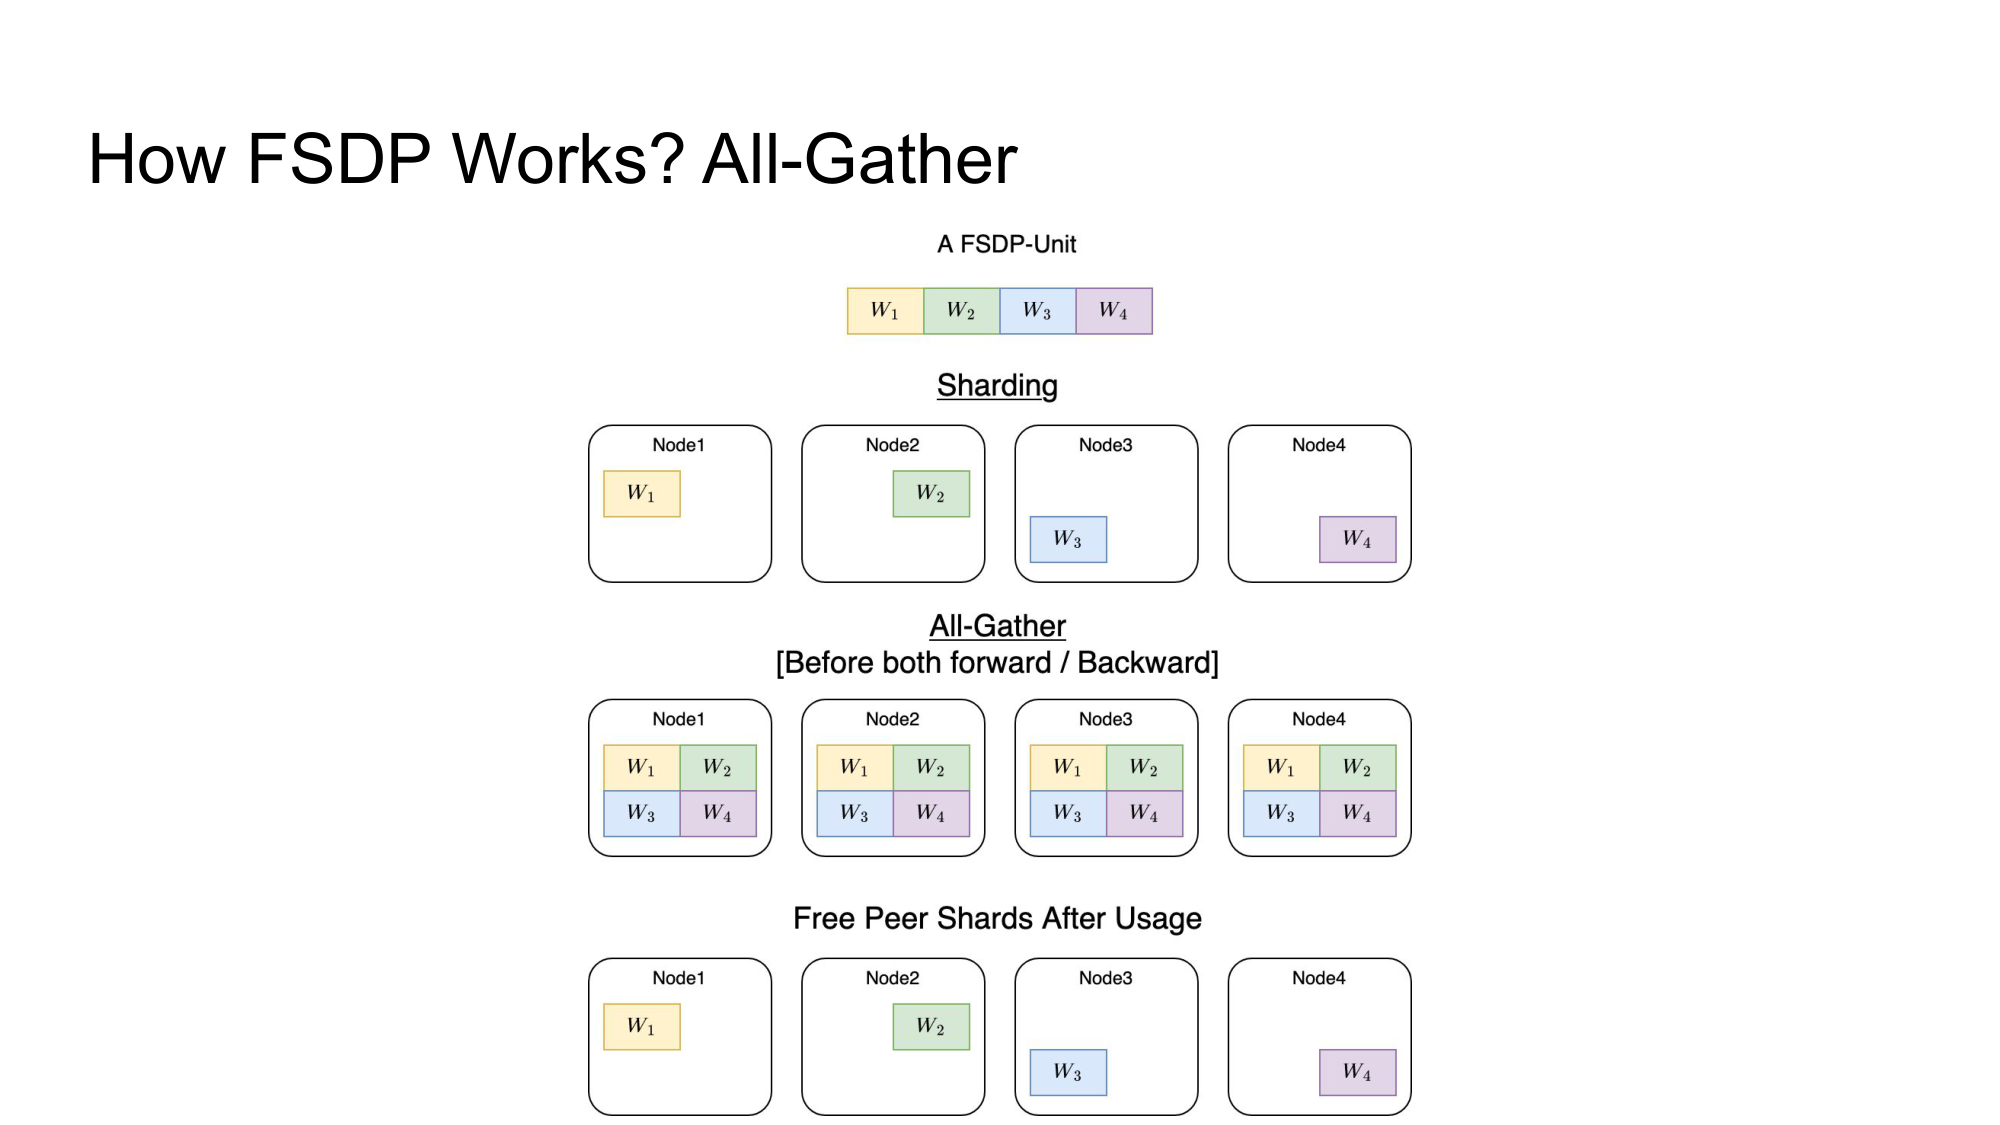

The flow for a single FSDP unit:

1. **Sharded state** — each node holds only its shard (W₁ on Node1, W₂ on Node2, etc.)
2. **AllGather** — before forward *or* backward, all shards are gathered so every node has the full [W₁, W₂, W₃, W₄]
3. **Compute** — forward or backward runs using the full parameters
4. **Free peer shards** — immediately after computation, the non-local shards are discarded. Each node returns to holding only its own shard

This "gather → compute → free" cycle is the core memory trick of FSDP. The peak memory at any moment is the **sharded model** plus the **one fully-materialized FSDP unit** currently being computed — not the entire model.

### Forward and Backward Execution Flow

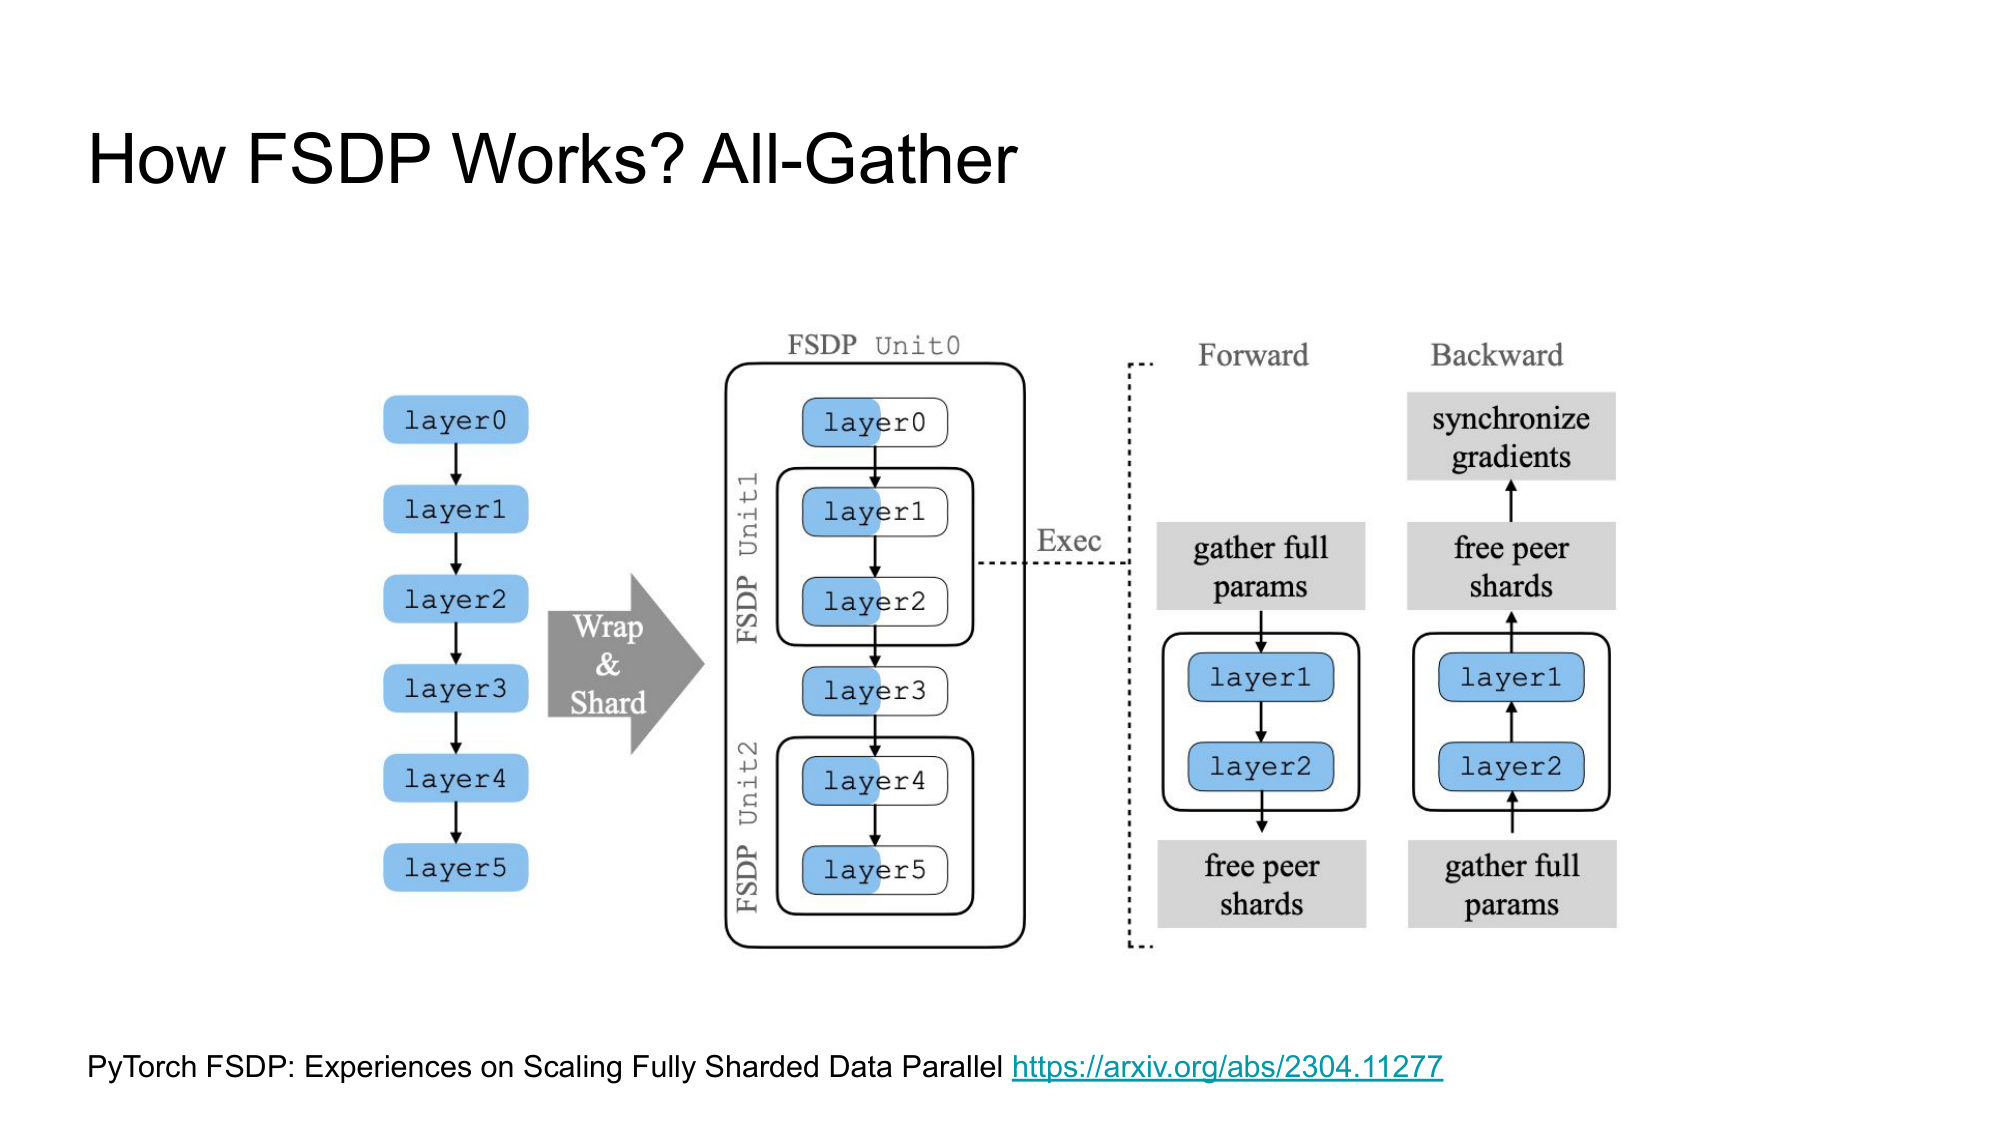

The left side shows the original model being **wrapped and sharded** into FSDP units. The right side shows what happens during execution:

**Forward pass (per FSDP unit):**
1. Gather full params (AllGather)
2. Run the layers in this unit
3. Free peer shards

**Backward pass (per FSDP unit, in reverse order):**
1. Gather full params (AllGather again — they were freed after forward)
2. Compute gradients
3. Free peer shards
4. Synchronize gradients (ReduceScatter)

### Overlapping Communication and Computation

FSDP pipelines the AllGather for the **next** FSDP unit while the **current** unit is still computing. This overlap is critical for hiding communication latency.

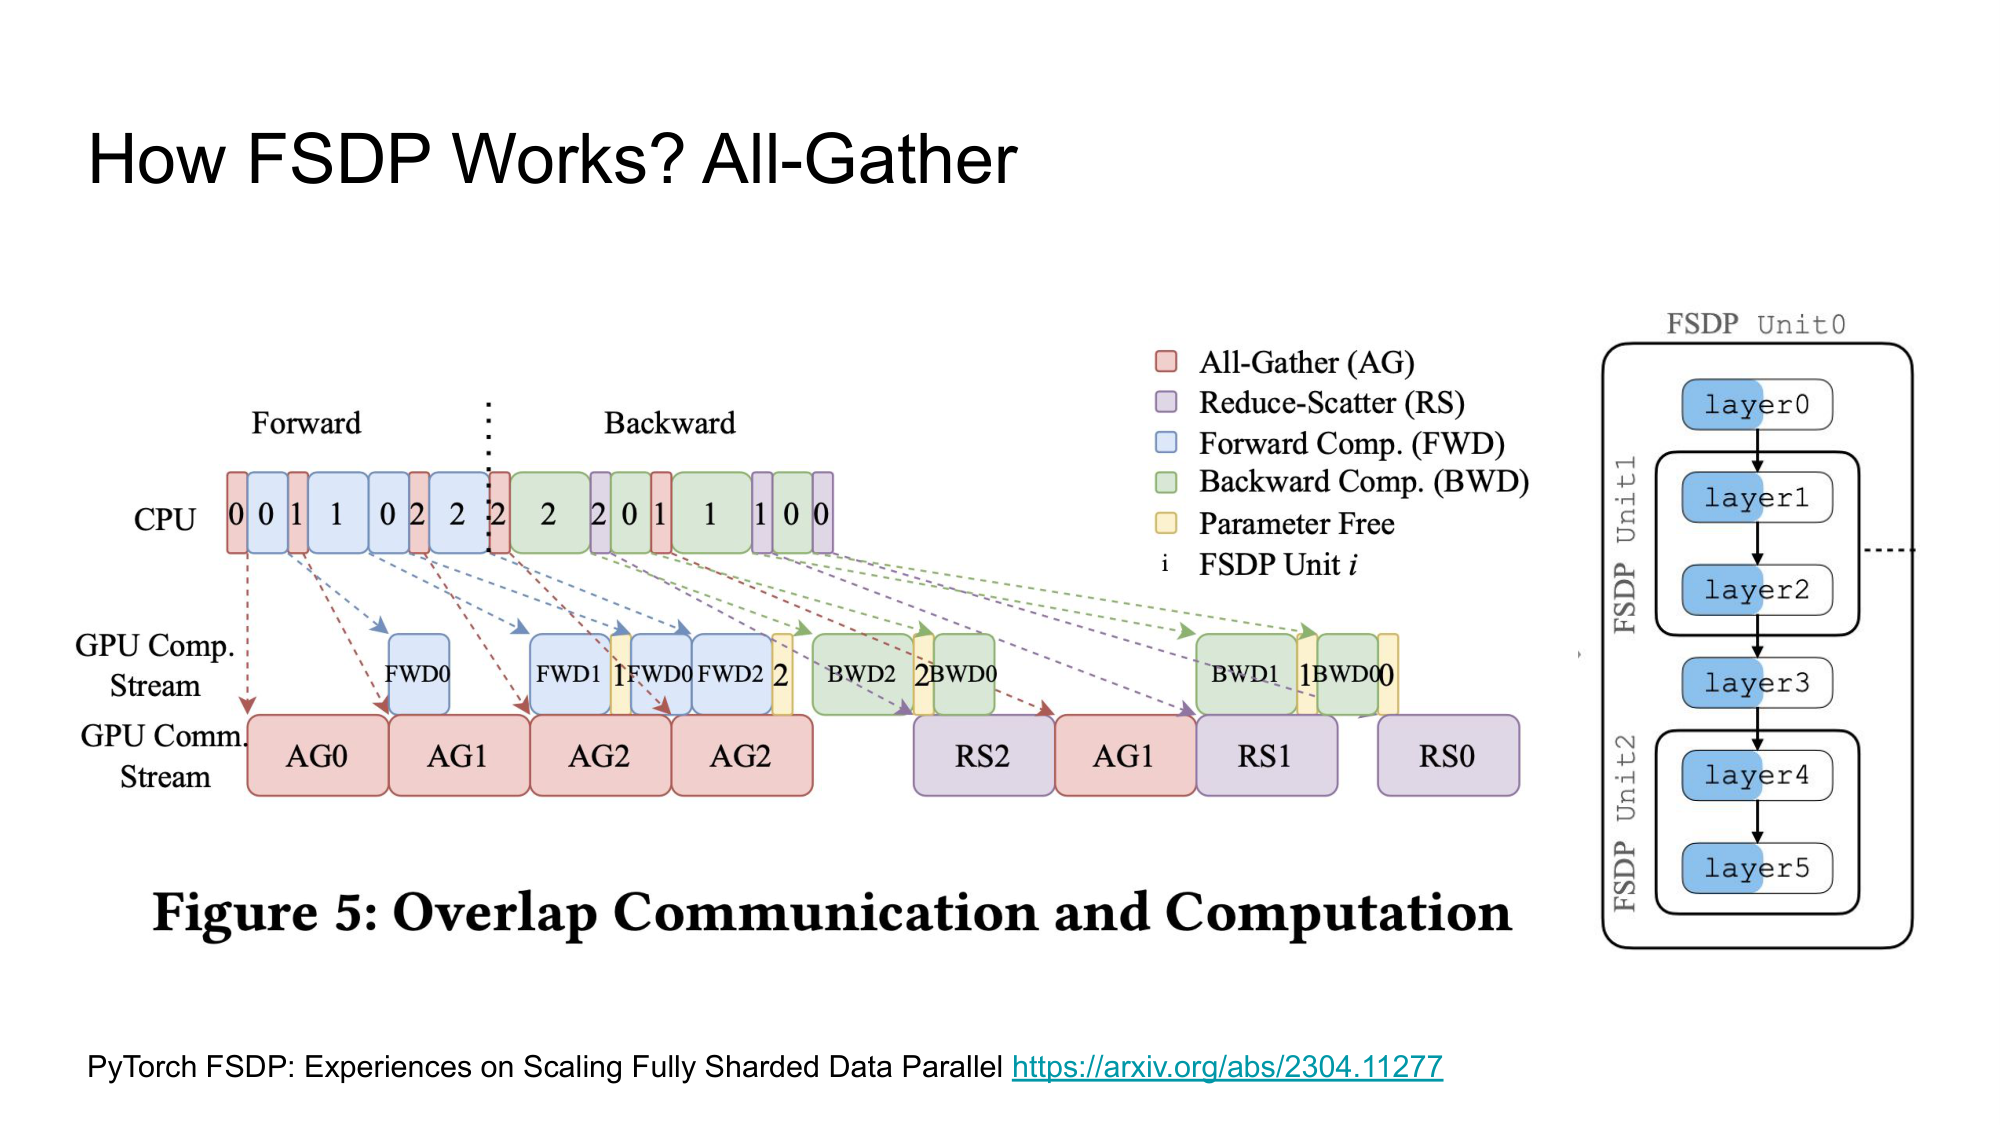

The timeline shows two GPU streams running in parallel:

- **GPU Compute Stream** — runs forward (FWD) and backward (BWD) computations
- **GPU Communication Stream** — runs AllGather (AG) and ReduceScatter (RS) operations

Notice how `AG1` (gathering Unit 1's params) overlaps with `FWD0` (computing Unit 0's forward). Similarly in the backward pass, `AG1` overlaps with `BWD2`. This prefetching is why FSDP with well-sized units can approach DDP throughput despite the extra communication.

---

## 4. ReduceScatter: Synchronizing and Re-sharding Gradients

After the backward pass, each GPU has local gradients for the full FSDP unit (because AllGather gave it full parameters). But different GPUs computed gradients on **different data batches** — so gradients G₁₁, G₂₁, G₃₁, G₄₁ are all different.

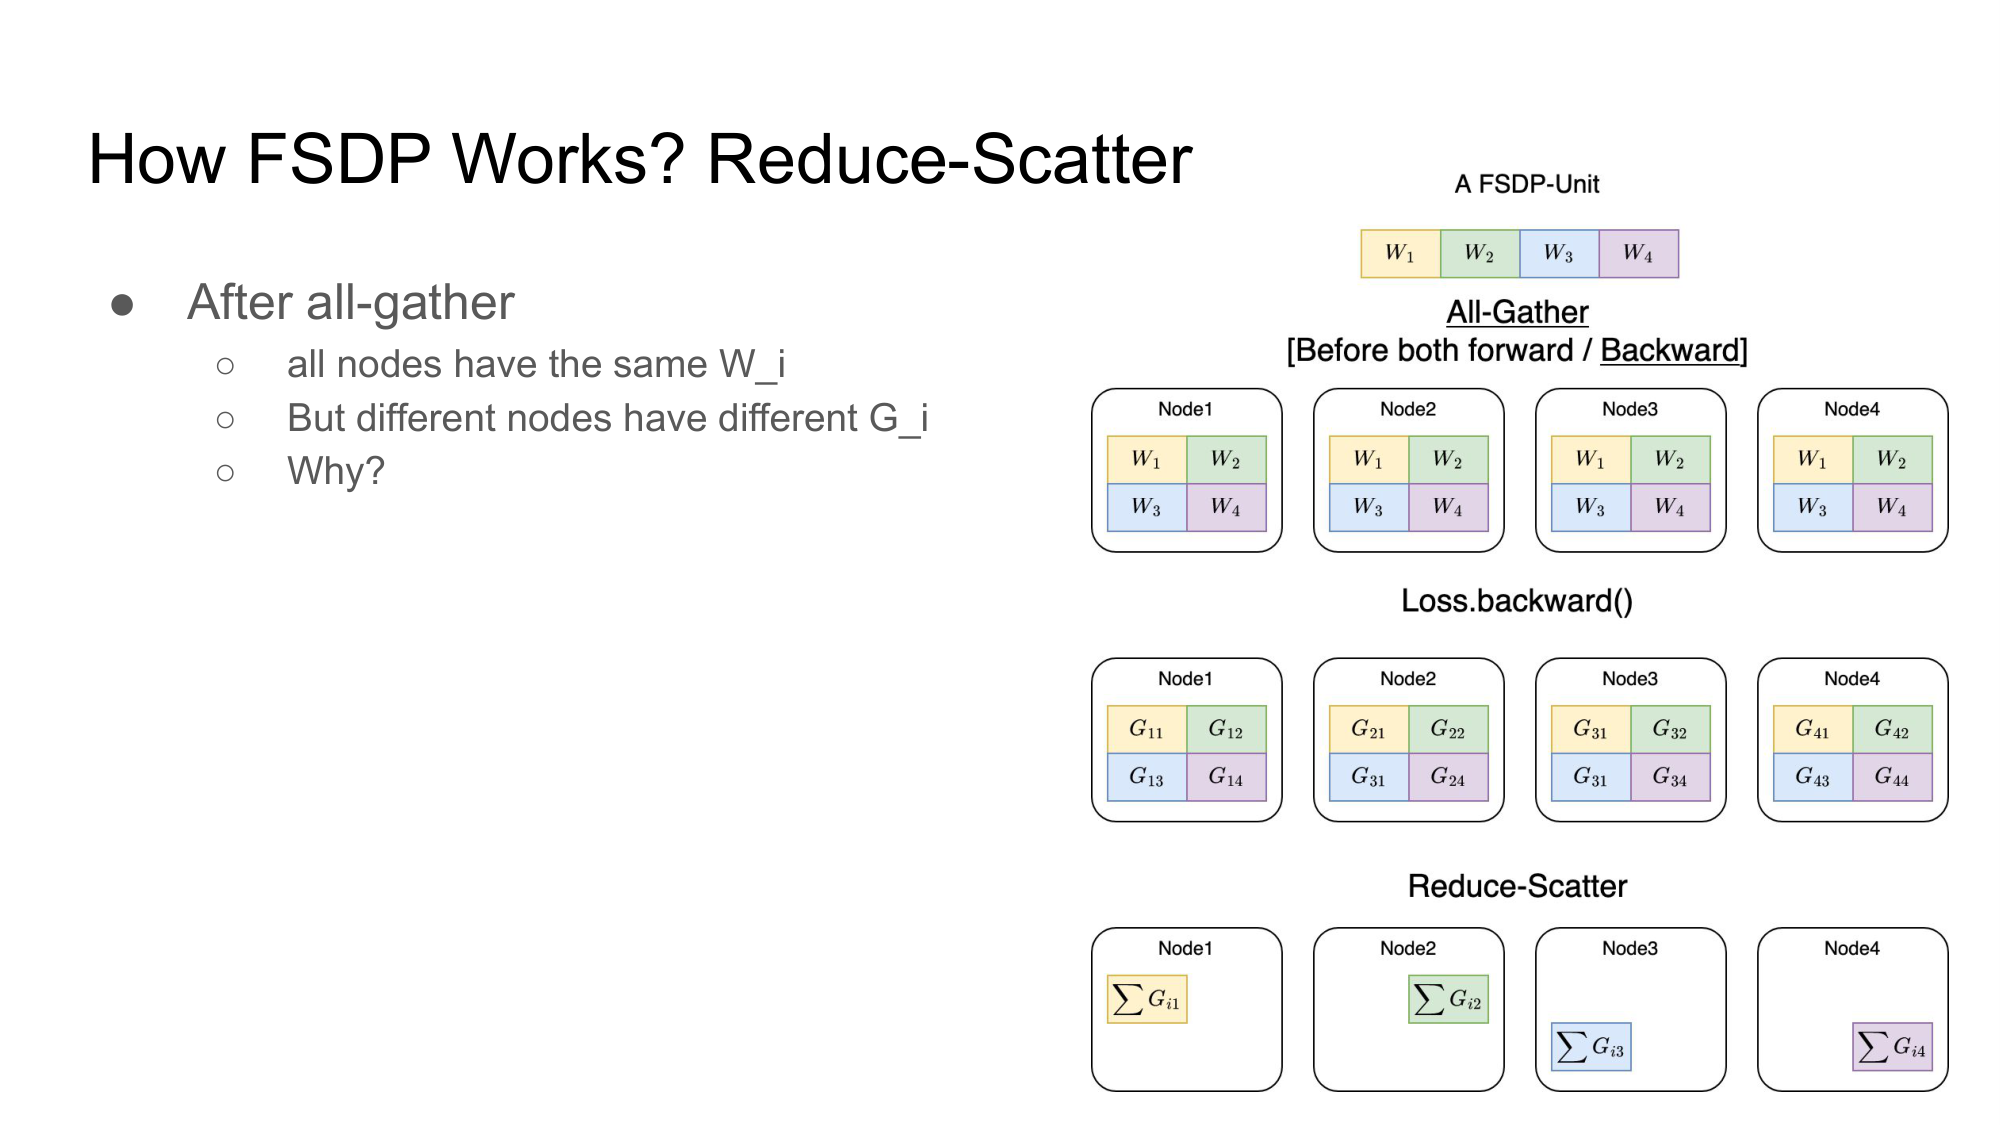

ReduceScatter does two things in one operation:

1. **Reduce** — sums gradients across all nodes (like AllReduce)
2. **Scatter** — each node receives only its **own shard** of the summed gradient

After ReduceScatter, Node 1 holds ΣGᵢ₁, Node 2 holds ΣGᵢ₂, etc. Each node then applies the optimizer update **only to its local shard** — it doesn't need the rest.

This is more memory-efficient than DDP's AllReduce, which gives every GPU the **full** gradient tensor. ReduceScatter keeps gradients sharded just like the parameters.

---

## DDP vs FSDP: The Key Difference

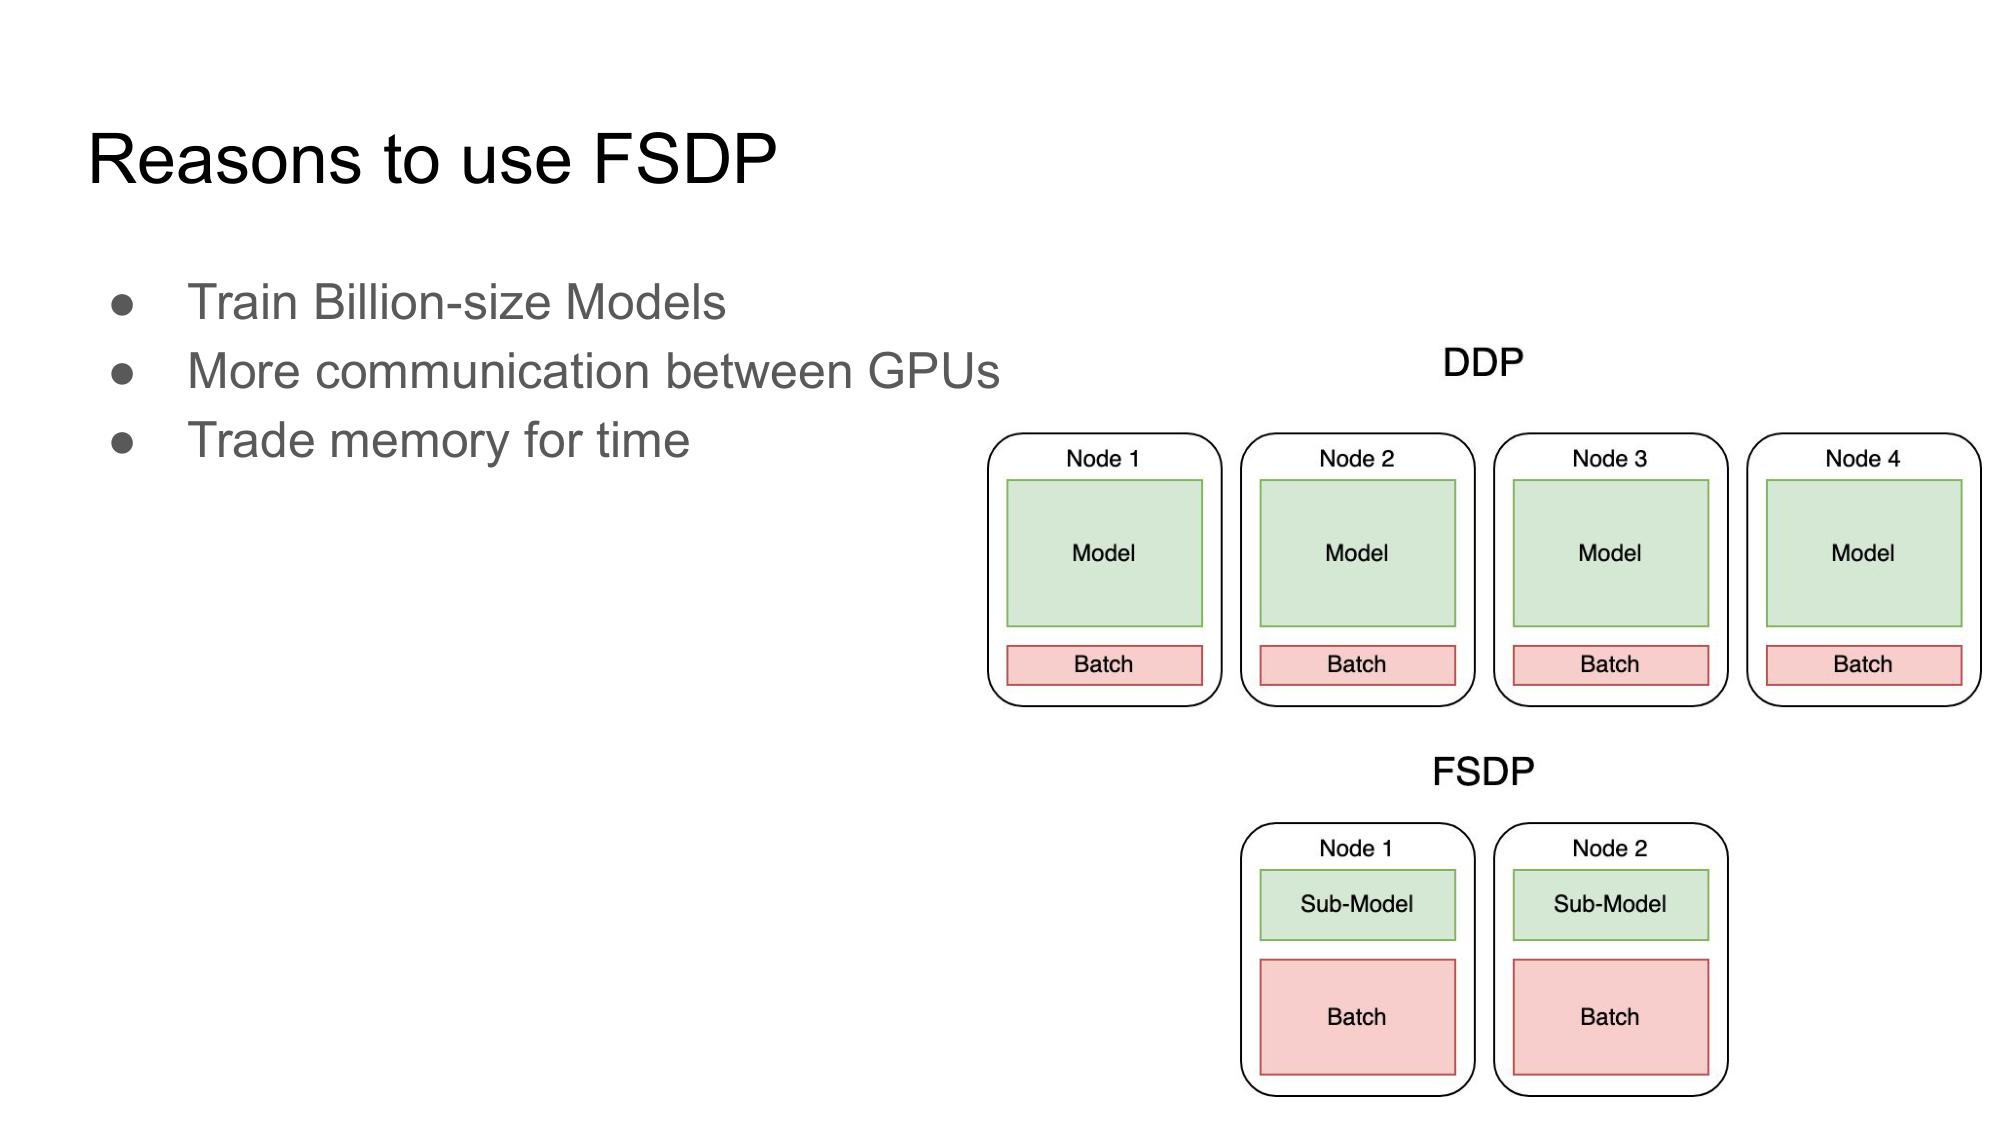

**DDP (top):** Every GPU holds the **full model**. Adding GPUs increases throughput but does NOT reduce per-GPU memory. A 7B model needs ~112 GB on every GPU regardless of how many you have.

**FSDP (bottom):** Each GPU holds a **sub-model** (shard). Adding GPUs reduces per-GPU memory proportionally. 2 GPUs = half the memory each. 64 GPUs = 1/64th each. This is what makes billion-parameter finetuning feasible.

---

## Communication Cost: DDP vs FSDP

| | DDP | FSDP (Full Shard) |
|---|---|---|
| **Forward** | None | AllGather per FSDP unit |
| **Backward** | AllReduce (gradients) | AllGather + ReduceScatter per unit |
| **Total volume** | 2Ψ | 3Ψ (~50% more) |
| **Memory per GPU** | (2+2+K)×Ψ | (2+2+K)×Ψ / N |

FSDP trades **1.5× communication for N× memory reduction**. For billion-parameter models where DDP is impossible (model doesn't fit on one GPU), this tradeoff isn't optional — it's the only path forward.

With good communication/computation overlap (prefetching AllGathers), the actual wall-clock overhead is typically 10–15%, not 50%.

---

## When to Use FSDP

**Use FSDP when:**
- Model doesn't fit on a single GPU with DDP
- You're finetuning models at the billion-parameter scale
- You have Ampere or newer GPUs (A100, H100) — bfloat16 support makes FSDP much smoother

**Think twice when:**
- Model is under ~100M parameters — consider activation checkpointing or gradient accumulation first
- You need partial finetuning (freezing layers) — FSDP makes this non-trivial and requires extra handling
- You only have consumer GPUs without NVLink — inter-GPU communication will be the bottleneck

**Practical notes:**
- **bfloat16 is strongly recommended** over float16. FP16 with FSDP requires `ShardedGradScaler` and runs ~4% slower due to rescaling overhead
- **Wrapping policy matters.** The built-in `size_based_auto_wrap_policy` is generic but suboptimal. A custom policy targeting your model's transformer block class (e.g., `LlamaDecoderLayer`) gives better communication efficiency
- **Code changes from DDP are minimal.** Replace `DistributedDataParallel(model)` with `FullyShardedDataParallel(model)` and handle checkpoint saving/loading for sharded state dicts

---

## FSDP in One Paragraph

FSDP wraps the model into **FSDP units**, flattens each unit's parameters into a **FlatParameter**, and **shards** it across GPUs. Before each unit's forward or backward pass, an **AllGather** reconstructs the full parameters temporarily. After backward, a **ReduceScatter** sums gradients across GPUs and re-shards them. This "gather → compute → free" cycle means each GPU only ever stores its shard plus one fully-materialized unit at a time — reducing memory proportionally to GPU count at the cost of ~50% more communication volume (which is largely hidden by overlapping communication with computation).

---

## References

- Zhao, Y., et al. (2023). *PyTorch FSDP: Experiences on Scaling Fully Sharded Data Parallel*. [arXiv:2304.11277](https://arxiv.org/abs/2304.11277)
- Rajbhandari, S., et al. (2019). *ZeRO: Memory Optimizations Toward Training Trillion Parameter Models*. [arXiv:1910.02054](https://arxiv.org/abs/1910.02054)
- Meta Engineering. (2021). *Fully Sharded Data Parallel: faster AI training with fewer GPUs*. [Blog](https://engineering.fb.com/2021/07/15/open-source/fsdp/)
- PyTorch. *FSDP Documentation*. [pytorch.org/docs/stable/fsdp.html](https://pytorch.org/docs/stable/fsdp.html)

[Source 1](https://docs.google.com/presentation/d/1ljBHf0z2elSuzy06UqF_N8MKiairDCUnuzMAPeUh7OA/edit?slide=id.gcb9a0b074_1_0#slide=id.gcb9a0b074_1_0)<br>

[Source 2](https://docs.google.com/presentation/d/1ntPSYg-Wphl8sErwjUl0AztOY1i4SZmQuvmGhkeRElA/edit?slide=id.p#slide=id.p)